# Исследование 

### Подготовка среды

Раздел посвящен настройке среды для работы

Импорты

In [279]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Настройки отображения

In [5]:
pd.set_option("display.max_rows", None)

Проверка наличия optuna и LightGBM после установки

In [245]:
import optuna

print("Optuna:", optuna.__version__)

Optuna: 4.9.0


In [246]:
import lightgbm as lgb

print("LightGBM:", lgb.__version__)

LightGBM: 4.7.0


### Сбор и склейка датасетов по нужным признакам

Данный раздел посвящен сбору и первичной подготовке данных для последующего feature engineering. Все данные взяты из открытых источников World Bank Enterprise Surveys.

Для исследования были выбраны датасеты следующих стран:
- Босния и Герцеговина
- Болгария
- Венгрия
- Ирландия
- Черногория
- Морокко
- Португалия
- Швеция
- Тунис

Ниже приведен полный процесс создания обработки сырых данных и создания двух датасетов для двух разных HGF таргетов: HGF по Sales и HGF по employees. 

##### Для обучения моделей и анализа будут использованы признаки, представленные в словаре ниже:

In [6]:
FEATURES = {
    # =========================
    # 1. Финансовые признаки
    # =========================
    "d2": "Продажи фирмы за последний завершенный финансовый год",
    "n3": "Продажи фирмы три финансовых года назад",
    "d1a3": "Доля основного продукта или услуги в общей выручке",

    "n2a": "Общие затраты на труд, включая заработную плату и выплаты работникам",
    "n2b": "Расходы на электроэнергию",
    "n2e": "Расходы на сырье и промежуточные материалы",
    "n2i": "Расходы на товары, приобретенные для перепродажи",

    "n5a": "Инвестиции в машины и оборудование",
    "n5b": "Инвестиции в землю и здания",
    "n7a": "Стоимость замещения имеющихся машин и оборудования",

    "k4": "Приобретала ли фирма основные средства",
    "k5a": "Доля инвестиций, профинансированная за счет собственных средств",
    "k5f": "Доля инвестиций, профинансированная за счет кредита поставщиков или авансов клиентов",
    "k5i": "Доля инвестиций, профинансированная за счет вкладов владельцев или нового капитала",

    "k7": "Наличие овердрафта",
    "k9": "Тип финансовой организации, выдавшей кредит",
    "k11": "Размер последнего кредита на момент его одобрения",
    "k13": "Требовалось ли обеспечение или залог для получения кредита",

    "k14a": "Использовались ли земля или здания в качестве залога",
    "k14b": "Использовались ли машины или оборудование в качестве залога",
    "k14c": "Использовалась ли дебиторская задолженность в качестве залога",
    "k14d": "Использовались ли личные активы владельцев в качестве залога",
    "k14e": "Использовался ли другой вид залога",

    "k17": "Причина, по которой фирма не обращалась за кредитом",
    "k21": "Проверялась ли финансовая отчетность внешним аудитором",
    "k30": "Насколько доступ к финансированию является препятствием для деятельности фирмы",

    # ==================================================
    # 2. Структура фирмы, собственность и менеджмент
    # ==================================================
    "a3": "Размер населенного пункта, в котором расположена фирма",
    "a7": "Является ли предприятие частью фирмы с несколькими подразделениями",
    "a9": "Ведется ли отдельная финансовая отчетность предприятия",
    "a11": "Является ли отчетность головного офиса независимой от других подразделений",

    "b1": "Юридическая форма предприятия",
    "b2a": "Доля внутренней частной собственности",
    "b2b": "Доля иностранной частной собственности",
    "b2c": "Доля государственной собственности",
    "b2d": "Доля прочих видов собственности",

    "b4": "Есть ли женщины среди владельцев предприятия",
    "b5": "Год начала деятельности предприятия",
    "b6": "Количество работников при создании предприятия",
    "b7": "Опыт топ-менеджера в данной отрасли",
    "b7a": "Является ли топ-менеджер женщиной",
    "b8": "Наличие международно признанного сертификата качества",

    # ================================================
    # 3. Рынок, экспорт, технологии и инновации
    # ================================================
    "d12a": "Доля материалов и ресурсов внутреннего происхождения",
    "d12b": "Доля импортных материалов и ресурсов",
    "d13": "Импортирует ли фирма материалы напрямую",

    "d3a": "Доля продаж на внутреннем рынке",
    "d3b": "Доля продаж через косвенный экспорт",
    "d3c": "Доля продаж через прямой экспорт",
    "d8": "Год начала экспортной деятельности",

    "e1": "Основной рынок главного продукта или услуги",
    "e11": "Конкурирует ли фирма с предприятиями неформального сектора",
    "e6": "Использует ли фирма технологии, лицензированные у иностранной компании",

    "c22b": "Наличие собственного веб-сайта",
    "h1": "Внедряла ли фирма новые или существенно улучшенные продукты или услуги",

    # =========================================
    # 4. Персонал и человеческий капитал
    # =========================================
    "l1": "Количество постоянных работников в последнем финансовом году",
    "l2": "Количество постоянных работников три финансовых года назад",

    "l3a": "Количество постоянных производственных работников",
    "l3b": "Количество постоянных непроизводственных работников",
    "l4b": "Количество низкоквалифицированных производственных работников",

    "l5": "Количество или доля женщин среди постоянных работников",
    "l5a": "Количество или доля женщин среди производственных работников",
    "l5b": "Количество или доля женщин среди непроизводственных работников",

    "l6": "Количество временных или сезонных работников",
    "l8": "Средняя продолжительность работы временных или сезонных работников",

    "l10": "Проводила ли фирма формальное обучение работников",
    "l11a": "Доля производственных работников, прошедших формальное обучение",
    "l11b": "Доля непроизводственных работников, прошедших формальное обучение",

    # =============================================
    # 5. Государственное регулирование и коррупция
    # =============================================
    "j2": "Доля времени руководства, затрачиваемая на выполнение требований государственных органов",
    "j3": "Проводились ли налоговые проверки предприятия",
    "j4": "Количество или частота налоговых проверок",
    "j5": "Ожидались ли неформальные платежи при налоговых проверках",

    "j6a": "Пыталась ли фирма получить государственный контракт",

    "j10": "Обращалась ли фирма за импортной лицензией",
    "j11": "Время, необходимое для получения импортной лицензии",
    "j12": "Ожидались ли неформальные платежи при получении импортной лицензии",

    "j13": "Обращалась ли фирма за операционной лицензией",
    "j14": "Время, необходимое для получения операционной лицензии",
    "j15": "Ожидались ли неформальные платежи при получении операционной лицензии",

    # ==================================
    # 6. Бизнес-среда и препятствия
    # ==================================
    "d30a": "Насколько транспорт является препятствием для деятельности фирмы",
    "d30b": "Насколько таможенное и торговое регулирование является препятствием",
    "g30a": "Насколько доступ к земле является препятствием",
    "h30": "Насколько судебная система является препятствием",
    "i30": "Насколько преступность, кражи и беспорядки являются препятствием",

    "j30a": "Насколько налоговые ставки являются препятствием",
    "j30c": "Насколько лицензирование и разрешения являются препятствием",
    "j30e": "Насколько политическая нестабильность является препятствием",
    "j30f": "Насколько коррупция является препятствием",

    "l30b": "Насколько недостаточная квалификация рабочей силы является препятствием",
    "m1a": "Главное препятствие для деятельности предприятия"
}

#### Загрузка данных

In [7]:
datasets = {
    'bos': pd.read_stata("Bosnia and Herzegovina _2009_2013_2019_2023_.dta", convert_categoricals=False),
    'bol': pd.read_stata("Bulgaria _2009_2013_2019_2023_.dta", convert_categoricals=False),
    'hun': pd.read_stata("Hungary _2009_2013_2019_2023_.dta", convert_categoricals=False),
    'irl': pd.read_stata("Ireland _2020_2024_.dta", convert_categoricals=False),
    'mon': pd.read_stata("Montenegro _2009_2013_2019_2023_.dta", convert_categoricals=False),
    'mor': pd.read_stata("Morocco-2013-2019-2023.dta", convert_categoricals=False),
    'por': pd.read_stata("Portugal_2019_2023.dta", convert_categoricals=False),
    'swe': pd.read_stata("Sweden _2014_2020_2024_.dta", convert_categoricals=False),
    'tun': pd.read_stata("Tunisia _2013_2020_2024_.dta", convert_categoricals=False)
}

Изучение датасетов:

Проверим, есть ли в датасетах все нужные нам признаки:

In [8]:
feature_cols = list(FEATURES.keys())

target_cols = [
    "d2",
    "n3",
    "l1",
    "l2",
    "a20y"
]

technical_cols = [
    "panelid",
    "year"
]

required_cols = technical_cols + feature_cols + target_cols


for country, df in datasets.items():
    print("=" * 70)
    print(country)
    print("Размер:", df.shape)

    missing = [col for col in required_cols if col not in df.columns]

    print("Найдено признаков:",
          len([col for col in feature_cols if col in df.columns]),
          "/",
          len(feature_cols))

    print("Отсутствует:", missing)

bos
Размер: (1434, 802)
Найдено признаков: 88 / 88
Отсутствует: ['a20y']
bol
Размер: (2063, 805)
Найдено признаков: 88 / 88
Отсутствует: ['a20y']
hun
Размер: (2237, 811)
Найдено признаков: 88 / 88
Отсутствует: ['a20y']
irl
Размер: (1215, 494)
Найдено признаков: 88 / 88
Отсутствует: []
mon
Размер: (567, 811)
Найдено признаков: 88 / 88
Отсутствует: ['a20y']
mor
Размер: (2101, 837)
Найдено признаков: 88 / 88
Отсутствует: ['a20y']
por
Размер: (2069, 559)
Найдено признаков: 88 / 88
Отсутствует: []
swe
Размер: (1791, 630)
Найдено признаков: 88 / 88
Отсутствует: ['a20y']
tun
Размер: (1852, 738)
Найдено признаков: 88 / 88
Отсутствует: ['a20y']


###### обработка a20y

In [9]:
for country, df in datasets.items():
    cols = [
        col for col in df.columns
        if "a20y" in col.lower()
    ]
    print(country, cols)

bos ['_2019_2023_a20y']
bol ['_2019_2023_a20y']
hun ['_2019_2023_a20y']
irl ['a20y']
mon ['_2019_2023_a20y']
mor ['_2019_2023_a20y']
por ['a20y']
swe ['_2020_2024_a20y', '_2014_a20ystart', '_2014_a20yend']
tun ['_2020_2024_a20y']


In [10]:
A20Y_COLUMNS = {
    "bos": "_2019_2023_a20y",
    "bol": "_2019_2023_a20y",
    "hun": "_2019_2023_a20y",
    "irl": "a20y",
    "mon": "_2019_2023_a20y",
    "mor": "_2019_2023_a20y",
    "por": "a20y",
    "swe": "_2020_2024_a20y",
    "tun": "_2020_2024_a20y",
}

In [11]:
for name, df in datasets.items():
    old_name = A20Y_COLUMNS[name]

    if old_name != "a20y":
        df.rename(columns={old_name: "a20y"}, inplace=True)

In [12]:
for country, df in datasets.items():
    cols = [
        col for col in df.columns
        if "a20y" in col.lower()
    ]
    print(country, cols)

bos ['a20y']
bol ['a20y']
hun ['a20y']
irl ['a20y']
mon ['a20y']
mor ['a20y']
por ['a20y']
swe ['a20y', '_2014_a20ystart', '_2014_a20yend']
tun ['a20y']


#### Создание единого датасета

Определение и проверки для baseline и target годов

In [13]:
PANEL_YEARS = {
    "bos": (2019, 2023),
    "bol": (2019, 2023),
    "hun": (2019, 2023),
    "mon": (2019, 2023),
    "mor": (2019, 2023),
    "por": (2019, 2023),

    "irl": (2020, 2024),
    "swe": (2020, 2024),
    "tun": (2020, 2024),
}

In [14]:
for name, df in datasets.items():
    print(name, sorted(df["year"].dropna().unique()))

bos [np.float32(2009.0), np.float32(2013.0), np.float32(2019.0), np.float32(2023.0)]
bol [np.float32(2009.0), np.float32(2013.0), np.float32(2019.0), np.float32(2023.0)]
hun [np.float32(2009.0), np.float32(2013.0), np.float32(2019.0), np.float32(2023.0)]
irl [np.float32(2020.0), np.float32(2024.0)]
mon [np.float32(2009.0), np.float32(2013.0), np.float32(2019.0), np.float32(2023.0)]
mor [np.float32(2013.0), np.float32(2019.0), np.float32(2023.0)]
por [np.float32(2019.0), np.float32(2023.0)]
swe [np.float32(2014.0), np.float32(2020.0), np.float32(2024.0)]
tun [np.float32(2013.0), np.float32(2020.0), np.float32(2024.0)]


In [15]:
panels = {}

for name, df in datasets.items():
    baseline_year, target_year = PANEL_YEARS[name]

    baseline = df[df["year"] == baseline_year].copy()
    target = df[df["year"] == target_year].copy()

    print(
        name,
        "baseline:", len(baseline),
        "target:", len(target)
    )

    panels[name] = {
        "baseline": baseline,
        "target": target
    }

bos baseline: 362 target: 351
bol baseline: 772 target: 710
hun baseline: 805 target: 831
irl baseline: 606 target: 609
mon baseline: 150 target: 151
mor baseline: 1096 target: 598
por baseline: 1062 target: 1007
swe baseline: 591 target: 600
tun baseline: 615 target: 645


Проверка панелей на присутствие в начале и конце опроса:

In [16]:
for name, p in panels.items():
    baseline = p["baseline"]
    target = p["target"]

    common_ids = set(baseline["panelid"]) & set(target["panelid"])

    print(
        name,
        "baseline:", len(baseline),
        "target:", len(target),
        "common:", len(common_ids)
    )

bos baseline: 362 target: 351 common: 131
bol baseline: 772 target: 710 common: 218
hun baseline: 805 target: 831 common: 295
irl baseline: 606 target: 609 common: 190
mon baseline: 150 target: 151 common: 87
mor baseline: 1096 target: 598 common: 280
por baseline: 1062 target: 1007 common: 308
swe baseline: 591 target: 600 common: 180
tun baseline: 615 target: 645 common: 105


Проверка на дубликаты

In [17]:
for name, p in panels.items():
    for period in ["baseline", "target"]:
        df = p[period]

        print(
            name,
            period,
            "duplicates:",
            df["panelid"].duplicated().sum()
        )

bos baseline duplicates: 0
bos target duplicates: 0
bol baseline duplicates: 0
bol target duplicates: 0
hun baseline duplicates: 0
hun target duplicates: 0
irl baseline duplicates: 0
irl target duplicates: 0
mon baseline duplicates: 0
mon target duplicates: 0
mor baseline duplicates: 0
mor target duplicates: 0
por baseline duplicates: 0
por target duplicates: 0
swe baseline duplicates: 0
swe target duplicates: 0
tun baseline duplicates: 0
tun target duplicates: 0


In [18]:
for name, p in panels.items():
    print(name)
    print(p["target"]["a20y"].value_counts(dropna=False))
    print()

bos
a20y
2022.0    351
Name: count, dtype: int64

bol
a20y
2022.0    710
Name: count, dtype: int64

hun
a20y
2022.0    831
Name: count, dtype: int64

irl
a20y
2023    418
2024    179
2022     12
Name: count, dtype: int64

mon
a20y
2022.0    150
2023.0      1
Name: count, dtype: int64

mor
a20y
2022.0    535
2023.0     63
Name: count, dtype: int64

por
a20y
2022    1000
2023       7
Name: count, dtype: int64

swe
a20y
2023.0    506
2024.0     61
2022.0     33
Name: count, dtype: int64

tun
a20y
2023.0    554
2024.0     91
Name: count, dtype: int64



In [19]:
FEATURE_TIMING = {
    "d2": "last_fiscal_year",
    "n3": "three_fiscal_years_ago",
    "b7": "survey_time",
    "c22b": "survey_time",
    "d3c": "last_fiscal_year",
    "h1": "previous_3_years",
    "l10": "last_fiscal_year",
}

In [20]:
EXPECTED_A20Y = {
    "bos": 2022,
    "bol": 2022,
    "hun": 2022,
    "mon": 2022,
    "mor": 2022,
    "por": 2022,

    "irl": 2023,
    "swe": 2023,
    "tun": 2023,
}

In [21]:
feature_cols = list(FEATURES.keys())

In [22]:
target_cols = [
    "panelid",
    "a20y",
    "d2",
    "n3",
    "l1",
    "l2"
]

In [23]:
prepared = {}

for name, p in panels.items():

    baseline = p["baseline"].copy()
    target = p["target"].copy()

    # Оставляем правильный финансовый период
    target = target[
        target["a20y"] == EXPECTED_A20Y[name]
    ].copy()

    # Признаки исходной волны
    baseline = baseline[
        ["panelid"] + feature_cols
    ].copy()

    # Данные будущей волны
    target = target[target_cols].copy()

    target = target.rename(columns={
        "d2": "sales_end",
        "n3": "sales_start",
        "l1": "employees_end",
        "l2": "employees_start",
        "a20y": "financial_year_end"
    })

    # Оставляем только фирмы, присутствующие в обеих волнах
    df = baseline.merge(
        target,
        on="panelid",
        how="inner"
    )

    df["country"] = name

    prepared[name] = df

    print(name, len(df))

bos 131
bol 218
hun 295
irl 148
mon 87
mor 252
por 305
swe 161
tun 103


Проверка заполненности колонок для target переменных

In [24]:
for name, df in prepared.items():

    print("=" * 60)
    print(name)

    print("Всего:", len(df))

    print(
        "sales_start заполнено:",
        df["sales_start"].notna().sum()
    )

    print(
        "sales_end заполнено:",
        df["sales_end"].notna().sum()
    )

    print(
        "employees_start заполнено:",
        df["employees_start"].notna().sum()
    )

    print(
        "sales_start > 0:",
        (df["sales_start"] > 0).sum()
    )

    print(
        "sales_end > 0:",
        (df["sales_end"] > 0).sum()
    )

    print(
        "employees_start >= 10:",
        (df["employees_start"] >= 10).sum()
    )

bos
Всего: 131
sales_start заполнено: 131
sales_end заполнено: 131
employees_start заполнено: 131
sales_start > 0: 127
sales_end > 0: 130
employees_start >= 10: 104
bol
Всего: 218
sales_start заполнено: 218
sales_end заполнено: 218
employees_start заполнено: 218
sales_start > 0: 213
sales_end > 0: 218
employees_start >= 10: 176
hun
Всего: 295
sales_start заполнено: 295
sales_end заполнено: 295
employees_start заполнено: 295
sales_start > 0: 282
sales_end > 0: 294
employees_start >= 10: 209
irl
Всего: 148
sales_start заполнено: 148
sales_end заполнено: 148
employees_start заполнено: 148
sales_start > 0: 146
sales_end > 0: 146
employees_start >= 10: 81
mon
Всего: 87
sales_start заполнено: 87
sales_end заполнено: 87
employees_start заполнено: 87
sales_start > 0: 82
sales_end > 0: 87
employees_start >= 10: 57
mor
Всего: 252
sales_start заполнено: 252
sales_end заполнено: 252
employees_start заполнено: 252
sales_start > 0: 249
sales_end > 0: 252
employees_start >= 10: 216
por
Всего: 305
sal

Отбор только ИНФОРМАТИВНЫХ (больших 0) значений таргетов

In [25]:
for name, df in prepared.items():
    df["sales_start"] = df["sales_start"].mask(df["sales_start"] < 0, np.nan)
    df["sales_end"] = df["sales_end"].mask(df["sales_end"] < 0, np.nan)

In [26]:
valid = (
    df["sales_start"].notna()
    & df["sales_end"].notna()
    & (df["sales_start"] > 0)
    & (df["employees_start"] >= 10)
)

In [27]:
sales_samples = {}

for name, df in prepared.items():
    df = df.copy()

    # Оставляем только фирмы, для которых можно корректно определить HGF
    valid = (
        df["sales_start"].notna()
        & df["sales_end"].notna()
        & df["employees_start"].notna()
        & (df["sales_start"] > 0)
        & (df["sales_end"] >= 0)
        & (df["employees_start"] >= 10)
    )

    df = df.loc[valid].copy()

    # Среднегодовой темп роста продаж за 3 года
    df["sales_cagr"] = (
        (df["sales_end"] / df["sales_start"]) ** (1 / 3) - 1
    )

    # HGF по продажам
    df["hgf_sales"] = (df["sales_cagr"] > 0.10).astype(int)

    sales_samples[name] = df

    print(
        name,
        "firms:", len(df),
        "HGF:", df["hgf_sales"].sum(),
        "HGF share:", round(df["hgf_sales"].mean() * 100, 1), "%"
    )

bos firms: 101 HGF: 41 HGF share: 40.6 %
bol firms: 172 HGF: 55 HGF share: 32.0 %
hun firms: 200 HGF: 112 HGF share: 56.0 %
irl firms: 80 HGF: 26 HGF share: 32.5 %
mon firms: 52 HGF: 29 HGF share: 55.8 %
mor firms: 216 HGF: 32 HGF share: 14.8 %
por firms: 231 HGF: 114 HGF share: 49.4 %
swe firms: 124 HGF: 27 HGF share: 21.8 %
tun firms: 64 HGF: 25 HGF share: 39.1 %


Финальное объединение датасетов в конечный:


In [28]:
master_df = pd.concat(
    sales_samples.values(),
    ignore_index=True
)

In [29]:
print("Всего фирм:", len(master_df))
print("HGF:", master_df["hgf_sales"].sum())
print("Non-HGF:", (master_df["hgf_sales"] == 0).sum())
print("Доля HGF:", master_df["hgf_sales"].mean())

Всего фирм: 1240
HGF: 461
Non-HGF: 779
Доля HGF: 0.3717741935483871


In [30]:
print(master_df.columns)

Index(['panelid', 'd2', 'n3', 'd1a3', 'n2a', 'n2b', 'n2e', 'n2i', 'n5a', 'n5b',
       'n7a', 'k4', 'k5a', 'k5f', 'k5i', 'k7', 'k9', 'k11', 'k13', 'k14a',
       'k14b', 'k14c', 'k14d', 'k14e', 'k17', 'k21', 'k30', 'a3', 'a7', 'a9',
       'a11', 'b1', 'b2a', 'b2b', 'b2c', 'b2d', 'b4', 'b5', 'b6', 'b7', 'b7a',
       'b8', 'd12a', 'd12b', 'd13', 'd3a', 'd3b', 'd3c', 'd8', 'e1', 'e11',
       'e6', 'c22b', 'h1', 'l1', 'l2', 'l3a', 'l3b', 'l4b', 'l5', 'l5a', 'l5b',
       'l6', 'l8', 'l10', 'l11a', 'l11b', 'j2', 'j3', 'j4', 'j5', 'j6a', 'j10',
       'j11', 'j12', 'j13', 'j14', 'j15', 'd30a', 'd30b', 'g30a', 'h30', 'i30',
       'j30a', 'j30c', 'j30e', 'j30f', 'l30b', 'm1a', 'financial_year_end',
       'sales_end', 'sales_start', 'employees_end', 'employees_start',
       'country', 'sales_cagr', 'hgf_sales'],
      dtype='str')


Таким образом данный датасет является исходным для HGF по Sales для начала работы с машинным обучением 

In [31]:
master_sales = master_df.copy()

Построим датасет для определения HGF по employees

In [32]:
employee_samples = {}

for name, df in prepared.items():
    df = df.copy()

    # Служебные отрицательные значения WBES -> NaN
    df["employees_start"] = df["employees_start"].mask(
        df["employees_start"] < 0,
        np.nan
    )

    df["employees_end"] = df["employees_end"].mask(
        df["employees_end"] < 0,
        np.nan
    )

    # Условия для определения HGF по занятости
    valid = (
        df["employees_start"].notna()
        & df["employees_end"].notna()
        & (df["employees_start"] >= 10)
        & (df["employees_end"] >= 0)
    )

    df = df.loc[valid].copy()

    # Среднегодовой рост занятости за 3 года
    df["employees_cagr"] = (
        (df["employees_end"] / df["employees_start"]) ** (1 / 3) - 1
    )

    # HGF по занятости
    df["hgf_employees"] = (
        df["employees_cagr"] > 0.10
    ).astype(int)

    employee_samples[name] = df

    print(
        name,
        "firms:", len(df),
        "HGF:", df["hgf_employees"].sum(),
        "HGF share:",
        round(df["hgf_employees"].mean() * 100, 1),
        "%"
    )

bos firms: 104 HGF: 6 HGF share: 5.8 %
bol firms: 176 HGF: 9 HGF share: 5.1 %
hun firms: 209 HGF: 16 HGF share: 7.7 %
irl firms: 81 HGF: 11 HGF share: 13.6 %
mon firms: 57 HGF: 3 HGF share: 5.3 %
mor firms: 216 HGF: 35 HGF share: 16.2 %
por firms: 231 HGF: 18 HGF share: 7.8 %
swe firms: 128 HGF: 7 HGF share: 5.5 %
tun firms: 71 HGF: 3 HGF share: 4.2 %


In [33]:
master_employees = pd.concat(
    employee_samples.values(),
    ignore_index=True
)

In [34]:
print("Всего фирм:", len(master_employees))
print("HGF:", master_employees["hgf_employees"].sum())
print(
    "Non-HGF:",
    (master_employees["hgf_employees"] == 0).sum()
)
print(
    "Доля HGF:",
    master_employees["hgf_employees"].mean()
)

Всего фирм: 1273
HGF: 108
Non-HGF: 1165
Доля HGF: 0.08483896307934014


### Обработка признаков

Данный раздел посвящен объемной обработке признаков. Обракботка включает в себя:

- Отсеивание малоинформативных признаков
- Заполнение пустых значений в данных
- Создание фичей для хранения информации о природе пропусков
- Кодировка категорий особым образом для возможности обучения древовидных ансамблевых и линейных моделей.
- Нормализация числовых атрибутов для возможности корректной работы с линейными моделями

##### Обработка null значений

Для начала посмотрим на nan values по каждой колонке в датасетах

In [35]:
print("NaN values in master_sales:")
master_sales.isna().sum().sort_values(ascending=False)

NaN values in master_sales:


a9                    1185
j15                   1141
j14                   1141
j11                   1105
j12                   1105
a11                   1072
n2i                   1051
l11a                  1014
l11b                  1014
k14c                   875
k14b                   875
k14a                   875
k14d                   875
k14e                   875
l8                     818
l5                     771
j4                     727
j5                     727
k5i                    667
k5a                    667
k5f                    667
k11                    639
k13                    639
k9                     639
d8                     633
n5a                    576
n5b                    576
l3a                    470
l4b                    470
l3b                    470
l5a                    469
n7a                    469
n2e                    469
l5b                    469
d13                    437
k17                    377
b1                       0
k

In [36]:
print("NaN values in master_employees:")
master_employees.isna().sum().sort_values(ascending=False)

NaN values in master_employees:


a9                    1214
j15                   1170
j14                   1170
j11                   1131
j12                   1131
a11                   1102
n2i                   1079
l11a                  1040
l11b                  1040
k14c                   894
k14b                   894
k14a                   894
k14d                   894
k14e                   894
l8                     835
l5                     789
j4                     745
j5                     745
k5i                    681
k5a                    681
k5f                    681
k11                    651
k13                    651
k9                     651
d8                     648
n5a                    587
n5b                    587
l3a                    485
l4b                    485
l3b                    485
l5a                    484
n7a                    484
n2e                    484
l5b                    484
d13                    442
k17                    392
sales_start             31
s

Пропуски вызваны как просто отсутствием данных, так и связаны с различными причинами и ответами опрошенных компаний, поэтому была выбрана следующая стратегия обработки признаков:

- Признаки с >70% пропусков будут удалены
- Остальные признаки будут заполнены медианой + к ним будет добавлен столбец с данными о причине отсутствия данных

Удаление признаков:

In [37]:
threshold = 0.70

features = list(FEATURES)

drop_cols = set(
    master_sales[features].columns[
        master_sales[features].isna().mean() > threshold
    ]
) | set(
    master_employees[features].columns[
        master_employees[features].isna().mean() > threshold
    ]
)

master_sales = master_sales.drop(columns=drop_cols)
master_employees = master_employees.drop(columns=drop_cols)

print("Удалено признаков:", len(drop_cols))
print("Удаленные признаки:", sorted(drop_cols))

Удалено признаков: 14
Удаленные признаки: ['a11', 'a9', 'j11', 'j12', 'j14', 'j15', 'k14a', 'k14b', 'k14c', 'k14d', 'k14e', 'l11a', 'l11b', 'n2i']


Среди данных встречаются следующие "отрицательные" коды требующие обработки

In [38]:
for name, df in {
    "master_sales": master_sales,
    "master_employees": master_employees
}.items():

    print(f"\n{name}")

    features = [col for col in FEATURES if col in df.columns]

    for value in range(-9, 0):
        count = (df[features] == value).sum().sum()

        if count:
            print(value, count)


master_sales
-9 2907
-8 125
-7 451
-6 8

master_employees
-9 2985
-8 129
-7 460
-6 8


Коды "-9", "-8", "-7" имеют одинаковое значение независимо от контекста конкретного признака. Для категории "-6" все же стоит изучить контекст, в котором он встречается, так как он, в свою очередь, может иметь разное значение в зависимости от выбранного признака.

In [39]:
for name, df in {
    "master_sales": master_sales,
    "master_employees": master_employees
}.items():

    print(f"\n{name}")

    features = [col for col in FEATURES if col in df.columns]

    for col in features:
        count = (df[col] == -6).sum()

        if count > 0:
            print(col, count)


master_sales
b8 8

master_employees
b8 8


Код "-6" встречается только в признаке b8. Тут он означает категорию "Still in progress", на которую и будет заменен

Для дальнейшей обработки необходимо разделить признаки на категориальные, бинарные, числовые и порядковые

In [40]:
NUMERIC_FEATURES = [
    "d2", "n3", "d1a3",
    "n2a", "n2b", "n2e",
    "n5a", "n5b", "n7a",
    "k5a", "k5f", "k5i", "k11",

    "b2a", "b2b", "b2c", "b2d",
    "b5", "b6", "b7",

    "d12a", "d12b",
    "d3a", "d3b", "d3c",
    "d8",

    "l1", "l2",
    "l3a", "l3b", "l4b",
    "l5", "l5a", "l5b",
    "l6", "l8",

    "j2", "j4"
]

In [41]:
BINARY_FEATURES = [
    "k4",
    "k7",
    "k13",
    "k21",

    "a7",

    "b4",
    "b7a",
    "b8",

    "d13",
    "e11",
    "e6",
    "c22b",
    "h1",

    "l10",

    "j3",
    "j5",
    "j6a",
    "j10",
    "j13"
]

In [42]:
CATEGORICAL_FEATURES = [
    "k9",
    "k17",

    "b1",

    "e1",

    "m1a"
]

In [43]:
ORDINAL_FEATURES = [
    "k30",
    "a3",

    "d30a",
    "d30b",
    "g30a",
    "h30",
    "i30",
    "j30a",
    "j30c",
    "j30e",
    "j30f",
    "l30b"
]

In [44]:
CAT_FEATURES = (
    BINARY_FEATURES
    + CATEGORICAL_FEATURES
    + ORDINAL_FEATURES
)

Далее для качественной обработки пропусков создадим столбцы status для каждой переменной, чтобы зафиксифровать причины пропуска того или иного значения

In [45]:
def process_missing_status(df):
    df = df.copy()

    # Числовые признаки
    for col in NUMERIC_FEATURES:

        mask = (
            df[col].isna()
            | df[col].isin([-7, -8, -9])
        )

        # Если проблемных значений нет, status не создаем
        if not mask.any():
            continue

        status_col = f"{col}_status"

        df[status_col] = "observed"

        df.loc[df[col] == -7, status_col] = "not_applicable"
        df.loc[df[col] == -8, status_col] = "refused"
        df.loc[df[col] == -9, status_col] = "dont_know"
        df.loc[df[col].isna(), status_col] = "missing"

        # После сохранения причины специальные коды превращаем в NaN
        df[col] = df[col].replace([-7, -8, -9], np.nan)

    # Категориальные признаки
    for col in CAT_FEATURES:
        df[col] = df[col].astype("object")

        df[col] = df[col].replace({
            -7: "not_applicable",
            -8: "refused",
            -9: "dont_know"
        })

        df[col] = df[col].fillna("missing")

    # Особый случай b8
    df["b8"] = df["b8"].replace({
        -6: "still_in_process"
    })

    return df

In [46]:
master_sales = process_missing_status(master_sales)
master_employees = process_missing_status(master_employees)

По завершении обработки было создано следующее количество новых столбцов:

In [47]:
status_cols_sales = [
    col for col in master_sales.columns
    if col.endswith("_status")
]

status_cols_employees = [
    col for col in master_employees.columns
    if col.endswith("_status")
]

print("Sales status columns:", len(status_cols_sales))
print("Employees status columns:", len(status_cols_employees))

Sales status columns: 38
Employees status columns: 38


Добавим новые столбцы к категориальным 

In [48]:
STATUS_FEATURES = [
    col for col in master_sales.columns
    if col.endswith("_status")
]

MODEL_CAT_FEATURES = CAT_FEATURES + STATUS_FEATURES + ["country"]
MODEL_FEATURES = NUMERIC_FEATURES + MODEL_CAT_FEATURES

Следующим шагом является импутация значений. Перед ней необходимо разделить данные на X и y, а так же train/test выборки, чтобы избежать ненужных утечек данных

In [49]:
X_sales = master_sales[MODEL_FEATURES].copy()
y_sales = master_sales["hgf_sales"].copy()

In [50]:
X_employees = master_employees[MODEL_FEATURES].copy()
y_employees = master_employees["hgf_employees"].copy()

In [51]:
from sklearn.model_selection import train_test_split

X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(
    X_sales,
    y_sales,
    test_size=0.2,
    stratify=y_sales,
    random_state=42
)

X_train_emp, X_test_emp, y_train_emp, y_test_emp = train_test_split(
    X_employees,
    y_employees,
    test_size=0.2,
    stratify=y_employees,
    random_state=42
)

In [52]:
print("Sales:")
print(len(X_train_sales), len(X_test_sales))
print(y_train_sales.value_counts())
print(y_test_sales.value_counts())

print("\nEmployees:")
print(len(X_train_emp), len(X_test_emp))
print(y_train_emp.value_counts())
print(y_test_emp.value_counts())

Sales:
992 248
hgf_sales
0    623
1    369
Name: count, dtype: int64
hgf_sales
0    156
1     92
Name: count, dtype: int64

Employees:
1018 255
hgf_employees
0    932
1     86
Name: count, dtype: int64
hgf_employees
0    233
1     22
Name: count, dtype: int64


После успешного разделения можно приступить к заполнению датасетов

In [53]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_sales[NUMERIC_FEATURES] = imputer.fit_transform(
    X_train_sales[NUMERIC_FEATURES]
)

X_test_sales[NUMERIC_FEATURES] = imputer.transform(
    X_test_sales[NUMERIC_FEATURES]
)

In [54]:
imputer_emp = SimpleImputer(strategy="median")

X_train_emp[NUMERIC_FEATURES] = imputer_emp.fit_transform(
    X_train_emp[NUMERIC_FEATURES]
)

X_test_emp[NUMERIC_FEATURES] = imputer_emp.transform(
    X_test_emp[NUMERIC_FEATURES]
)

##### Выбор моделей

Выбирая baseline модель и модели для дальнейшего сравнения, было решено остановиться на следующих вариантах:

Для baseline модели использовать классический LogisticClassifier

Для дальнейшего исследования будут использоваться RandomForestClassifier, LightGBM, HistGradientBoost, SVC, KNN

Выбор обоснован различной структурой моделей

##### Кодировка признаков

Чтобы обучить данные модели необходимо закодировать категориальные признаки, а также нормализовать числовые. Нормализация числовых признаков нужна только для логистической и SVC модели, и для этих же моделей будут созданы два датасета с one-hot encoding, в то время как нормализация для остальных моделей использоваться не будет, а категории будут закодированы при помощи ordinal encoder.

Для начала, все категории должны быть приведены к строчному типу:

In [55]:
for df in [
    X_train_sales,
    X_test_sales,
    X_train_emp,
    X_test_emp
]:
    df[MODEL_CAT_FEATURES] = df[MODEL_CAT_FEATURES].astype(str)

После этого, можно начинать непосредственную кодировку значений

Произведем one-hot encoding категориальных признаков

In [56]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ohe_sales = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            MODEL_CAT_FEATURES
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

X_train_sales_ohe = ohe_sales.fit_transform(X_train_sales)
X_test_sales_ohe = ohe_sales.transform(X_test_sales)

ohe_sales.set_output(transform="pandas")

X_train_sales_ohe = ohe_sales.transform(X_train_sales)
X_test_sales_ohe = ohe_sales.transform(X_test_sales)

In [57]:
ohe_emp = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            MODEL_CAT_FEATURES
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

ohe_emp.fit(X_train_emp)
ohe_emp.set_output(transform="pandas")

X_train_emp_ohe = ohe_emp.transform(X_train_emp)
X_test_emp_ohe = ohe_emp.transform(X_test_emp)

Далее следует обычная кодировка категорий при помощи ordinal encoding

In [58]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_sales = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            MODEL_CAT_FEATURES
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

ordinal_sales.fit(X_train_sales)
ordinal_sales.set_output(transform="pandas")

X_train_sales_ord = ordinal_sales.transform(X_train_sales)
X_test_sales_ord = ordinal_sales.transform(X_test_sales)

In [59]:
ordinal_emp = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            MODEL_CAT_FEATURES
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

ordinal_emp.fit(X_train_emp)
ordinal_emp.set_output(transform="pandas")

X_train_emp_ord = ordinal_emp.transform(X_train_emp)
X_test_emp_ord = ordinal_emp.transform(X_test_emp)

Robust scaling:

In [60]:
from sklearn.preprocessing import RobustScaler

# =========================
# SALES
# =========================

X_train_sales_linear = X_train_sales_ohe.copy()
X_test_sales_linear = X_test_sales_ohe.copy()

scaler_sales = RobustScaler()

X_train_sales_linear[NUMERIC_FEATURES] = scaler_sales.fit_transform(
    X_train_sales_linear[NUMERIC_FEATURES]
)

X_test_sales_linear[NUMERIC_FEATURES] = scaler_sales.transform(
    X_test_sales_linear[NUMERIC_FEATURES]
)


# =========================
# EMPLOYEES
# =========================

X_train_employees_linear = X_train_emp_ohe.copy()
X_test_employees_linear = X_test_emp_ohe.copy()

scaler_employees = RobustScaler()

X_train_employees_linear[NUMERIC_FEATURES] = scaler_employees.fit_transform(
    X_train_employees_linear[NUMERIC_FEATURES]
)

X_test_employees_linear[NUMERIC_FEATURES] = scaler_employees.transform(
    X_test_employees_linear[NUMERIC_FEATURES]
)

In [61]:
X_train_sales_tree = X_train_sales_ord.copy()
X_test_sales_tree = X_test_sales_ord.copy()

X_train_employees_tree = X_train_emp_ord.copy()
X_test_employees_tree = X_test_emp_ord.copy()

In [62]:
y_train_employees = y_train_emp.copy()
y_test_employees = y_test_emp.copy()

Таким образом были получены следующие датасеты для обучения моделей:

Для SALES HGF

Linear / SVC:
- X_train_sales_linear
- X_test_sales_linear
- y_train_sales
- y_test_sales

Trees:
- X_train_sales_tree
- X_test_sales_tree
- y_train_sales
- y_test_sales


Для EMPLOYEES HGF

Linear / SVC:
- X_train_employees_linear
- X_test_employees_linear
- y_train_employees
- y_test_employees

Trees:
- X_train_employees_tree
- X_test_employees_tree
- y_train_employees
- y_test_employees

### Обучение моделей на всем датасете

Данный раздел включает в себя большое количество кода для корректного обучения моделей, подбора их параметров и сбора данных о результатах обучения моделей.

Для подбора оптимальных параметров моделей будет использоваться библиотека optuna.

Оптимизируемой метрикой послужит MCC, так как сочитает в себе TP, TN, FP, FN предсказания. Это хорошо подходит для оптимизации всех моделей и позволяет отслеживать реальную производительность и точность модели

##### Обучение baseline модели

Для начала обучим линейную модель

In [128]:
import optuna

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    matthews_corrcoef,
    make_scorer,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mcc_scorer = make_scorer(matthews_corrcoef)

Обучающая функция для optuna

In [129]:
def tune_logreg(
    X_train,
    y_train,
    class_weight=None,
    n_trials=50
):

    def objective(trial):

        params = {
            "C": trial.suggest_float(
                "C",
                1e-3,
                1e2,
                log=True
            ),

            "l1_ratio": trial.suggest_float(
                "l1_ratio",
                0.0,
                1.0
            ),

            "solver": "saga",
            "max_iter": 5000,
            "tol": 1e-3,
            "class_weight": class_weight,
            "random_state": 42
        }

        model = LogisticRegression(**params)

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=mcc_scorer
        )

        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    return study

Подберем параметры:

In [130]:
# study_sales = tune_logreg(
#     X_train_sales_linear,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )

# SALES
# Best CV MCC: -0.053021811082285555
# Best params: {'C': 0.009484811678557923, 'l1_ratio': 0.8010501808769005}


In [131]:
# study_employees = tune_logreg(
#     X_train_employees_linear,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )

# EMPLOYEES
# Best CV MCC: -0.008484626247673164
# Best params: {'C': 0.001267425589893723, 'l1_ratio': 0.9699098521619943}

Лучшие параметры:

In [132]:
# print("SALES")
# print("Best CV MCC:", study_sales.best_value)
# print("Best params:", study_sales.best_params)

# print("\nEMPLOYEES")
# print("Best CV MCC:", study_employees.best_value)
# print("Best params:", study_employees.best_params)

SALES
Best CV MCC: -0.053021811082285555
Best params: {'C': 0.009484811678557923, 'l1_ratio': 0.8010501808769005}

EMPLOYEES
Best CV MCC: -0.008484626247673164
Best params: {'C': 0.001267425589893723, 'l1_ratio': 0.9699098521619943}

Создание моделей с лучшими параметрами

In [133]:
def build_logreg(best_params, class_weight=None):

    return LogisticRegression(
        **best_params,
        solver="saga",
        max_iter=5000,
        class_weight=class_weight,
        random_state=42
    )

In [134]:
logreg_sales = build_logreg(
    # study_sales.best_params,
    {'C': 0.009484811678557923, 'l1_ratio': 0.8010501808769005},
    class_weight=None
)

logreg_employees = build_logreg(
    # study_employees.best_params,
    {'C': 0.001267425589893723, 'l1_ratio': 0.9699098521619943},
    class_weight="balanced"
)

In [135]:
logreg_sales.fit(
    X_train_sales_linear,
    y_train_sales
)

logreg_employees.fit(
    X_train_employees_linear,
    y_train_employees
)

C:\Users\yafil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.001267425589893723
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.9699098521619943
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic A

In [136]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "MCC": matthews_corrcoef(
            y_test,
            y_pred
        ),

        "PR-AUC": average_precision_score(
            y_test,
            y_prob
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),

        "F1": f1_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        )
    }

In [137]:
sales_results = evaluate_model(
    logreg_sales,
    X_test_sales_linear,
    y_test_sales
)

employees_results = evaluate_model(
    logreg_employees,
    X_test_employees_linear,
    y_test_employees
)

# print("SALES")
# print(sales_results)

# print("\nEMPLOYEES")
# print(employees_results)

Таким образом результаты baseline модели могут быть занесены в следующюю таблицу:

In [138]:
baseline_results = pd.DataFrame([
    {
        "target": "sales",
        "model": "LogisticRegression",
        **sales_results
    },
    {
        "target": "employees",
        "model": "LogisticRegression",
        **employees_results
    }
])

baseline_results

,target,model,MCC,PR-AUC,ROC-AUC,F1,Recall,Precision,Balanced Accuracy,Accuracy
0,sales,LogisticRegression,-0.044778,0.366573,0.453456,0.351064,0.358696,0.343750,0.477425,0.508065
1,employees,LogisticRegression,-0.094708,0.075683,0.384120,0.103896,0.363636,0.060606,0.415724,0.458824


##### Обучение Random Forest

In [139]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


def tune_random_forest(
    X_train,
    y_train,
    class_weight=None,
    n_trials=50
):

    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int(
                "n_estimators",
                200,
                1000,
                step=100
            ),

            "max_depth": trial.suggest_categorical(
                "max_depth",
                [None, 4, 6, 8, 10, 12, 16, 20]
            ),

            "min_samples_split": trial.suggest_int(
                "min_samples_split",
                2,
                20
            ),

            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                1,
                10
            ),

            "max_features": trial.suggest_float(
                "max_features",
                0.2,
                1.0
            ),

            "criterion": trial.suggest_categorical(
                "criterion",
                ["gini", "entropy", "log_loss"]
            ),

            "bootstrap": trial.suggest_categorical(
                "bootstrap",
                [True, False]
            ),

            "class_weight": class_weight,
            "random_state": 42,
            "n_jobs": -1
        }

        model = RandomForestClassifier(**params)

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=mcc_scorer,
            n_jobs=-1
        )

        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    return study

In [140]:
# study_rf_sales = tune_random_forest(
#     X_train_sales_tree,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )

In [141]:
# study_rf_employees = tune_random_forest(
#     X_train_employees_tree,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )

In [142]:
# print("SALES")
# print("Best CV MCC:", study_rf_sales.best_value)
# print("Best params:", study_rf_sales.best_params)
# SALES
# Best CV MCC: 0.17542168087222942
# Best params: {'n_estimators': 600, 'max_depth': None, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': 0.3198743571407685, 'criterion': 'gini', 'bootstrap': False}


# print("\nEMPLOYEES")
# print("Best CV MCC:", study_rf_employees.best_value)
# print("Best params:", study_rf_employees.best_params)
# EMPLOYEES
# Best CV MCC: 0.1711076263706539
# Best params: {'n_estimators': 700, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.20153396960677564, 'criterion': 'gini', 'bootstrap': False}

In [143]:
def build_random_forest(
    best_params,
    class_weight=None
):

    return RandomForestClassifier(
        **best_params,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

In [145]:
rf_sales = build_random_forest(
    {'n_estimators': 600, 'max_depth': None, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': 0.3198743571407685, 'criterion': 'gini', 'bootstrap': False},
    # study_rf_sales.best_params,
    class_weight=None
)

rf_employees = build_random_forest(
    {'n_estimators': 700, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.20153396960677564, 'criterion': 'gini', 'bootstrap': False},
    # study_rf_employees.best_params,
    class_weight="balanced"
)

In [146]:
rf_sales.fit(
    X_train_sales_tree,
    y_train_sales
)

rf_employees.fit(
    X_train_employees_tree,
    y_train_employees
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.20153396960677564
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion

In [147]:
rf_sales_results = evaluate_model(
    rf_sales,
    X_test_sales_tree,
    y_test_sales
)

rf_employees_results = evaluate_model(
    rf_employees,
    X_test_employees_tree,
    y_test_employees
)

# print("SALES")
# print(rf_sales_results)

# print("\nEMPLOYEES")
# print(rf_employees_results)

SALES
{'MCC': 0.24784671946801892, 'PR-AUC': 0.5483317093069388, 'ROC-AUC': 0.7023411371237458, 'F1': 0.425531914893617, 'Recall': 0.32608695652173914, 'Precision': 0.6122448979591837, 'Balanced Accuracy': 0.6021460423634337, 'Accuracy': 0.6733870967741935}

EMPLOYEES
{'MCC': 0.2041971901958841, 'PR-AUC': 0.24697369153285284, 'ROC-AUC': 0.6915723761217324, 'F1': 0.08695652173913043, 'Recall': 0.045454545454545456, 'Precision': 1.0, 'Balanced Accuracy': 0.5227272727272727, 'Accuracy': 0.9176470588235294}

In [148]:
model_results = baseline_results.copy()

In [149]:
rf_results = pd.DataFrame([
    {
        "target": "sales",
        "model": "RandomForest",
        **rf_sales_results
    },
    {
        "target": "employees",
        "model": "RandomForest",
        **rf_employees_results
    }
])

model_results = pd.concat(
    [model_results, rf_results],
    ignore_index=True
)

model_results

,target,model,MCC,PR-AUC,ROC-AUC,F1,Recall,Precision,Balanced Accuracy,Accuracy
0,sales,LogisticRegression,-0.044778,0.366573,0.453456,0.351064,0.358696,0.343750,0.477425,0.508065
1,employees,LogisticRegression,-0.094708,0.075683,0.384120,0.103896,0.363636,0.060606,0.415724,0.458824
2,sales,RandomForest,0.247847,0.548332,0.702341,0.425532,0.326087,0.612245,0.602146,0.673387
3,employees,RandomForest,0.204197,0.246974,0.691572,0.086957,0.045455,1.000000,0.522727,0.917647


##### Обучение Hist Gradient Boosting модели

In [150]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score


def tune_hgb(
    X_train,
    y_train,
    class_weight=None,
    n_trials=50
):

    def objective(trial):

        params = {
            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.01,
                0.3,
                log=True
            ),

            "max_iter": trial.suggest_int(
                "max_iter",
                100,
                800,
                step=50
            ),

            "max_leaf_nodes": trial.suggest_int(
                "max_leaf_nodes",
                7,
                63
            ),

            "min_samples_leaf": trial.suggest_int(
                "min_samples_leaf",
                5,
                50
            ),

            "l2_regularization": trial.suggest_float(
                "l2_regularization",
                1e-8,
                10.0,
                log=True
            ),

            "max_bins": trial.suggest_categorical(
                "max_bins",
                [64, 128, 255]
            ),

            "early_stopping": False,
            "class_weight": class_weight,
            "random_state": 42
        }

        model = HistGradientBoostingClassifier(**params)

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=mcc_scorer,
            n_jobs=-1
        )

        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    return study

In [151]:
# study_hgb_sales = tune_hgb(
#     X_train_sales_tree,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )

In [152]:
# study_hgb_employees = tune_hgb(
#     X_train_employees_tree,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )

In [153]:
# print("SALES")
# print("Best CV MCC:", study_hgb_sales.best_value)
# print("Best params:", study_hgb_sales.best_params)
# SALES
# Best CV MCC: 0.1733126360929475
# Best params: {'learning_rate': 0.0507426868462551, 'max_iter': 200, 'max_leaf_nodes': 60, 'min_samples_leaf': 21, 'l2_regularization': 0.41587179434799904, 'max_bins': 64}

# print("\nEMPLOYEES")
# print("Best CV MCC:", study_hgb_employees.best_value)
# print("Best params:", study_hgb_employees.best_params)
# EMPLOYEES
# Best CV MCC: 0.20893497568977018
# Best params: {'learning_rate': 0.17024585445474397, 'max_iter': 350, 'max_leaf_nodes': 38, 'min_samples_leaf': 13, 'l2_regularization': 2.390235958936141e-05, 'max_bins': 255}

In [154]:
def build_hgb(
    best_params,
    class_weight=None
):

    return HistGradientBoostingClassifier(
        **best_params,
        early_stopping=False,
        class_weight=class_weight,
        random_state=42
    )

In [155]:
hgb_sales = build_hgb(
    {'learning_rate': 0.0507426868462551, 'max_iter': 200, 'max_leaf_nodes': 60, 'min_samples_leaf': 21, 'l2_regularization': 0.41587179434799904, 'max_bins': 64},
    # study_hgb_sales.best_params,
    class_weight=None
)

hgb_employees = build_hgb(
    {'learning_rate': 0.17024585445474397, 'max_iter': 350, 'max_leaf_nodes': 38, 'min_samples_leaf': 13, 'l2_regularization': 2.390235958936141e-05, 'max_bins': 255},
    # study_hgb_employees.best_params,
    class_weight="balanced"
)

In [156]:
hgb_sales.fit(
    X_train_sales_tree,
    y_train_sales
)

hgb_employees.fit(
    X_train_employees_tree,
    y_train_employees
)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.17024585445474397
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",350
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",38
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",13
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",2.390235958936141e-05
,"early_stopping early_stopping: 'auto' or bool, default='auto'If 'auto', early stopping is enabled if the sample size is larger than10000 or if `X_val` and `y_val` are passed to `fit`. If True, early stoppingis enabled, otherwise early stopping is disabled... versionadded:: 0.23",False
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form `{class_label: weight}`.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas `n_samples / (n_classes * np.bincount(y))`.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if `sample_weight` is specified... versionadded:: 1.2",'balanced'
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0


In [157]:
hgb_sales_results = evaluate_model(
    hgb_sales,
    X_test_sales_tree,
    y_test_sales
)

hgb_employees_results = evaluate_model(
    hgb_employees,
    X_test_employees_tree,
    y_test_employees
)

print("SALES")
print(hgb_sales_results)

print("\nEMPLOYEES")
print(hgb_employees_results)

SALES
{'MCC': 0.23519983140882128, 'PR-AUC': 0.5544839993270575, 'ROC-AUC': 0.6723104793756968, 'F1': 0.4429530201342282, 'Recall': 0.358695652173913, 'Precision': 0.5789473684210527, 'Balanced Accuracy': 0.6024247491638796, 'Accuracy': 0.6653225806451613}

EMPLOYEES
{'MCC': 0.2984231507631313, 'PR-AUC': 0.25057309513159737, 'ROC-AUC': 0.7116660163870465, 'F1': 0.23076923076923078, 'Recall': 0.13636363636363635, 'Precision': 0.75, 'Balanced Accuracy': 0.5660358954350371, 'Accuracy': 0.9215686274509803}


SALES
Best CV MCC: 0.1733126360929475
Best params: {'learning_rate': 0.0507426868462551, 'max_iter': 200, 'max_leaf_nodes': 60, 'min_samples_leaf': 21, 'l2_regularization': 0.41587179434799904, 'max_bins': 64}

EMPLOYEES
Best CV MCC: 0.20893497568977018
Best params: {'learning_rate': 0.17024585445474397, 'max_iter': 350, 'max_leaf_nodes': 38, 'min_samples_leaf': 13, 'l2_regularization': 2.390235958936141e-05, 'max_bins': 255}

In [158]:
hgb_results = pd.DataFrame([
    {
        "target": "sales",
        "model": "HistGradientBoosting",
        **hgb_sales_results
    },
    {
        "target": "employees",
        "model": "HistGradientBoosting",
        **hgb_employees_results
    }
])

model_results = pd.concat(
    [model_results, hgb_results],
    ignore_index=True
)

model_results

,target,model,MCC,PR-AUC,ROC-AUC,F1,Recall,Precision,Balanced Accuracy,Accuracy
0,sales,LogisticRegression,-0.044778,0.366573,0.453456,0.351064,0.358696,0.343750,0.477425,0.508065
1,employees,LogisticRegression,-0.094708,0.075683,0.384120,0.103896,0.363636,0.060606,0.415724,0.458824
2,sales,RandomForest,0.247847,0.548332,0.702341,0.425532,0.326087,0.612245,0.602146,0.673387
3,employees,RandomForest,0.204197,0.246974,0.691572,0.086957,0.045455,1.000000,0.522727,0.917647
4,sales,HistGradientBoosting,0.235200,0.554484,0.672310,0.442953,0.358696,0.578947,0.602425,0.665323
5,employees,HistGradientBoosting,0.298423,0.250573,0.711666,0.230769,0.136364,0.750000,0.566036,0.921569


##### Обучение LightGBM

In [159]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score


def tune_lightgbm(
    X_train,
    y_train,
    class_weight=None,
    n_trials=50
):

    def objective(trial):

        max_depth = trial.suggest_int(
            "max_depth",
            3,
            8
        )

        params = {
            "n_estimators": trial.suggest_int(
                "n_estimators",
                200,
                1200,
                step=50
            ),

            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.005,
                0.2,
                log=True
            ),

            "max_depth": max_depth,

            "num_leaves": trial.suggest_int(
                "num_leaves",
                7,
                min(63, 2 ** max_depth)
            ),

            "min_child_samples": trial.suggest_int(
                "min_child_samples",
                5,
                50
            ),

            "subsample": trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),

            "colsample_bytree": trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            ),

            "reg_alpha": trial.suggest_float(
                "reg_alpha",
                1e-8,
                10.0,
                log=True
            ),

            "reg_lambda": trial.suggest_float(
                "reg_lambda",
                1e-8,
                10.0,
                log=True
            ),

            "subsample_freq": 1,
            "class_weight": class_weight,
            "random_state": 42,

            # CV распараллеливаем снаружи
            "n_jobs": 1,

            # убираем служебный вывод LightGBM
            "verbosity": -1
        }

        model = LGBMClassifier(**params)

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=mcc_scorer,
            n_jobs=-1
        )

        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    return study

In [160]:
# study_lgbm_sales = tune_lightgbm(
#     X_train_sales_tree,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )

In [161]:
# study_lgbm_employees = tune_lightgbm(
#     X_train_employees_tree,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )

In [162]:
# print("SALES")
# print("Best CV MCC:", study_lgbm_sales.best_value)
# print("Best params:", study_lgbm_sales.best_params)
# SALES
# Best CV MCC: 0.14592203743841875
# Best params: {'max_depth': 5, 'n_estimators': 700, 'learning_rate': 0.005269077020309735, 'num_leaves': 22, 'min_child_samples': 37, 'subsample': 0.8251969998703916, 'colsample_bytree': 0.9091911422801686, 'reg_alpha': 4.399629844940822e-07, 'reg_lambda': 1.6468177519646233e-07}

# print("\nEMPLOYEES")
# print("Best CV MCC:", study_lgbm_employees.best_value)
# print("Best params:", study_lgbm_employees.best_params)
# EMPLOYEES
# Best CV MCC: 0.2029720025865059
# Best params: {'max_depth': 8, 'n_estimators': 950, 'learning_rate': 0.026924568000275897, 'num_leaves': 58, 'min_child_samples': 33, 'subsample': 0.882570299211053, 'colsample_bytree': 0.9594721868821656, 'reg_alpha': 1.9001668960692104e-05, 'reg_lambda': 4.50026966235878e-08}

In [163]:
def build_lightgbm(
    best_params,
    class_weight=None
):

    return LGBMClassifier(
        **best_params,
        subsample_freq=1,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

In [164]:
lgbm_sales = build_lightgbm(
    {'max_depth': 5, 'n_estimators': 700, 'learning_rate': 0.005269077020309735, 'num_leaves': 22, 'min_child_samples': 37, 'subsample': 0.8251969998703916, 'colsample_bytree': 0.9091911422801686, 'reg_alpha': 4.399629844940822e-07, 'reg_lambda': 1.6468177519646233e-07},
    # study_lgbm_sales.best_params,
    class_weight=None
)

lgbm_employees = build_lightgbm(
    {'max_depth': 8, 'n_estimators': 950, 'learning_rate': 0.026924568000275897, 'num_leaves': 58, 'min_child_samples': 33, 'subsample': 0.882570299211053, 'colsample_bytree': 0.9594721868821656, 'reg_alpha': 1.9001668960692104e-05, 'reg_lambda': 4.50026966235878e-08},
    # study_lgbm_employees.best_params,
    class_weight="balanced"
)

In [165]:
lgbm_sales.fit(
    X_train_sales_tree,
    y_train_sales
)

lgbm_employees.fit(
    X_train_employees_tree,
    y_train_employees
)

,num_leaves,58
,max_depth,8
,learning_rate,0.026924568000275897
,n_estimators,950
,class_weight,'balanced'
,min_child_samples,33
,subsample,0.882570299211053
,subsample_freq,1
,colsample_bytree,0.9594721868821656
,reg_alpha,1.9001668960692104e-05
,reg_lambda,4.50026966235878e-08


In [166]:
lgbm_sales_results = evaluate_model(
    lgbm_sales,
    X_test_sales_tree,
    y_test_sales
)

lgbm_employees_results = evaluate_model(
    lgbm_employees,
    X_test_employees_tree,
    y_test_employees
)

print("SALES")
print(lgbm_sales_results)

print("\nEMPLOYEES")
print(lgbm_employees_results)

SALES
{'MCC': 0.2551531431987477, 'PR-AUC': 0.5505628304728404, 'ROC-AUC': 0.68373745819398, 'F1': 0.4117647058823529, 'Recall': 0.30434782608695654, 'Precision': 0.6363636363636364, 'Balanced Accuracy': 0.600891861761427, 'Accuracy': 0.6774193548387096}

EMPLOYEES
{'MCC': 0.2984231507631313, 'PR-AUC': 0.2568293811836933, 'ROC-AUC': 0.704447912602419, 'F1': 0.23076923076923078, 'Recall': 0.13636363636363635, 'Precision': 0.75, 'Balanced Accuracy': 0.5660358954350371, 'Accuracy': 0.9215686274509803}


SALES
{'MCC': 0.2551531431987477, 'PR-AUC': 0.5505628304728404, 'ROC-AUC': 0.68373745819398, 'F1': 0.4117647058823529, 'Recall': 0.30434782608695654, 'Precision': 0.6363636363636364, 'Balanced Accuracy': 0.600891861761427, 'Accuracy': 0.6774193548387096}

EMPLOYEES
{'MCC': 0.2984231507631313, 'PR-AUC': 0.2568293811836933, 'ROC-AUC': 0.704447912602419, 'F1': 0.23076923076923078, 'Recall': 0.13636363636363635, 'Precision': 0.75, 'Balanced Accuracy': 0.5660358954350371, 'Accuracy': 0.9215686274509803}

In [167]:
lgbm_results = pd.DataFrame([
    {
        "target": "sales",
        "model": "LightGBM",
        **lgbm_sales_results
    },
    {
        "target": "employees",
        "model": "LightGBM",
        **lgbm_employees_results
    }
])

model_results = pd.concat(
    [model_results, lgbm_results],
    ignore_index=True
)

model_results

,target,model,MCC,PR-AUC,ROC-AUC,F1,Recall,Precision,Balanced Accuracy,Accuracy
0,sales,LogisticRegression,-0.044778,0.366573,0.453456,0.351064,0.358696,0.343750,0.477425,0.508065
1,employees,LogisticRegression,-0.094708,0.075683,0.384120,0.103896,0.363636,0.060606,0.415724,0.458824
2,sales,RandomForest,0.247847,0.548332,0.702341,0.425532,0.326087,0.612245,0.602146,0.673387
3,employees,RandomForest,0.204197,0.246974,0.691572,0.086957,0.045455,1.000000,0.522727,0.917647
4,sales,HistGradientBoosting,0.235200,0.554484,0.672310,0.442953,0.358696,0.578947,0.602425,0.665323
5,employees,HistGradientBoosting,0.298423,0.250573,0.711666,0.230769,0.136364,0.750000,0.566036,0.921569
6,sales,LightGBM,0.255153,0.550563,0.683737,0.411765,0.304348,0.636364,0.600892,0.677419
7,employees,LightGBM,0.298423,0.256829,0.704448,0.230769,0.136364,0.750000,0.566036,0.921569


##### Обучение SVC

In [168]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score


def tune_svc(
    X_train,
    y_train,
    class_weight=None,
    n_trials=50
):

    def objective(trial):

        params = {
            "C": trial.suggest_float(
                "C",
                1e-3,
                1e3,
                log=True
            ),

            "gamma": trial.suggest_float(
                "gamma",
                1e-5,
                1.0,
                log=True
            ),

            "kernel": "rbf",
            "class_weight": class_weight
        }

        model = SVC(**params)

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=mcc_scorer,
            n_jobs=-1
        )

        return scores.mean()

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42)
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    return study

In [169]:
# study_svc_sales = tune_svc(
#     X_train_sales_linear,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )
# SALES
# Best CV MCC: 0.04987685098543239
# Best params: {'C': 4.076636959540618, 'gamma': 1.2679518214698495e-05}

In [170]:
# study_svc_employees = tune_svc(
#     X_train_employees_linear,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )
# EMPLOYEES
# Best CV MCC: 0.07052551057874537
# Best params: {'C': 24.658329458549105, 'gamma': 0.009846738873614562}

In [171]:
# print("SALES")
# print("Best CV MCC:", study_svc_sales.best_value)
# print("Best params:", study_svc_sales.best_params)
# SALES
# Best CV MCC: 0.04987685098543239
# Best params: {'C': 4.076636959540618, 'gamma': 1.2679518214698495e-05}

# print("\nEMPLOYEES")
# print("Best CV MCC:", study_svc_employees.best_value)
# print("Best params:", study_svc_employees.best_params)
# EMPLOYEES
# Best CV MCC: 0.07052551057874537
# Best params: {'C': 24.658329458549105, 'gamma': 0.009846738873614562}

In [172]:
def build_svc(
    best_params,
    class_weight=None
):

    return SVC(
        **best_params,
        kernel="rbf",
        class_weight=class_weight
    )

In [173]:
svc_sales = build_svc(
    {'C': 4.076636959540618, 'gamma': 1.2679518214698495e-05},
    # study_svc_sales.best_params,
    class_weight=None
)

svc_employees = build_svc(
    {'C': 24.658329458549105, 'gamma': 0.009846738873614562},
    # study_svc_employees.best_params,
    class_weight="balanced"
)

In [174]:
svc_sales.fit(
    X_train_sales_linear,
    y_train_sales
)

svc_employees.fit(
    X_train_employees_linear,
    y_train_employees
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",24.658329458549105
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.009846738873614562
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [175]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    return {
        "MCC": matthews_corrcoef(
            y_test,
            y_pred
        ),

        "PR-AUC": average_precision_score(
            y_test,
            y_score
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            y_score
        ),

        "F1": f1_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        )
    }

In [176]:
svc_sales_results = evaluate_model(
    svc_sales,
    X_test_sales_linear,
    y_test_sales
)

svc_employees_results = evaluate_model(
    svc_employees,
    X_test_employees_linear,
    y_test_employees
)

print("SALES")
print(svc_sales_results)

print("\nEMPLOYEES")
print(svc_employees_results)

SALES
{'MCC': -0.1584358923978291, 'PR-AUC': 0.37407913362415335, 'ROC-AUC': 0.49592391304347827, 'F1': 0.036036036036036036, 'Recall': 0.021739130434782608, 'Precision': 0.10526315789473684, 'Balanced Accuracy': 0.45638238573021184, 'Accuracy': 0.5685483870967742}

EMPLOYEES
{'MCC': -0.01928042139188605, 'PR-AUC': 0.08857613996928368, 'ROC-AUC': 0.47619976589933666, 'F1': 0.0, 'Recall': 0.0, 'Precision': 0.0, 'Balanced Accuracy': 0.4978540772532189, 'Accuracy': 0.9098039215686274}


In [177]:
svc_results = pd.DataFrame([
    {
        "target": "sales",
        "model": "SVC",
        **svc_sales_results
    },
    {
        "target": "employees",
        "model": "SVC",
        **svc_employees_results
    }
])

model_results = pd.concat(
    [model_results, svc_results],
    ignore_index=True
)

model_results

,target,model,MCC,PR-AUC,ROC-AUC,F1,Recall,Precision,Balanced Accuracy,Accuracy
0,sales,LogisticRegression,-0.044778,0.366573,0.453456,0.351064,0.358696,0.343750,0.477425,0.508065
1,employees,LogisticRegression,-0.094708,0.075683,0.384120,0.103896,0.363636,0.060606,0.415724,0.458824
2,sales,RandomForest,0.247847,0.548332,0.702341,0.425532,0.326087,0.612245,0.602146,0.673387
3,employees,RandomForest,0.204197,0.246974,0.691572,0.086957,0.045455,1.000000,0.522727,0.917647
4,sales,HistGradientBoosting,0.235200,0.554484,0.672310,0.442953,0.358696,0.578947,0.602425,0.665323
5,employees,HistGradientBoosting,0.298423,0.250573,0.711666,0.230769,0.136364,0.750000,0.566036,0.921569
6,sales,LightGBM,0.255153,0.550563,0.683737,0.411765,0.304348,0.636364,0.600892,0.677419
7,employees,LightGBM,0.298423,0.256829,0.704448,0.230769,0.136364,0.750000,0.566036,0.921569
8,sales,SVC,-0.158436,0.374079,0.495924,0.036036,0.021739,0.105263,0.456382,0.568548
9,employees,SVC,-0.019280,0.088576,0.476200,0.000000,0.000000,0.000000,0.497854,0.909804


### Выводы по обучению моделей на всем датасете

Для более обоснованного и точного анализа будет использоваться устойчивый способ оценки моделей с помощью кросс-валидации 

##### Кросс-валидация моделей

In [178]:
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    matthews_corrcoef,
    precision_score
)


final_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=123
)


cv_scoring = {
    "MCC": make_scorer(matthews_corrcoef),
    "PR-AUC": "average_precision",
    "ROC-AUC": "roc_auc",
    "F1": "f1",
    "Recall": "recall",
    "Precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "Balanced Accuracy": "balanced_accuracy",
    "Accuracy": "accuracy"
}

In [179]:
def evaluate_cv(
    model,
    X,
    y,
    target,
    model_name
):

    # Берём модель с уже найденными гиперпараметрами
    cv_model = clone(model)

    # Избегаем двойного распараллеливания
    if "n_jobs" in cv_model.get_params():
        cv_model.set_params(n_jobs=1)

    scores = cross_validate(
        cv_model,
        X,
        y,
        cv=final_cv,
        scoring=cv_scoring,
        n_jobs=-1
    )

    result = {
        "target": target,
        "model": model_name
    }

    for metric in cv_scoring:

        values = scores[f"test_{metric}"]

        result[f"{metric}_mean"] = values.mean()
        result[f"{metric}_std"] = values.std()

    return result

In [180]:
cv_tasks = [

    # SALES

    (
        "sales",
        "LogisticRegression",
        logreg_sales,
        X_train_sales_linear,
        y_train_sales
    ),

    (
        "sales",
        "RandomForest",
        rf_sales,
        X_train_sales_tree,
        y_train_sales
    ),

    (
        "sales",
        "HistGradientBoosting",
        hgb_sales,
        X_train_sales_tree,
        y_train_sales
    ),

    (
        "sales",
        "LightGBM",
        lgbm_sales,
        X_train_sales_tree,
        y_train_sales
    ),

    (
        "sales",
        "SVC",
        svc_sales,
        X_train_sales_linear,
        y_train_sales
    ),


    # EMPLOYEES

    (
        "employees",
        "LogisticRegression",
        logreg_employees,
        X_train_employees_linear,
        y_train_employees
    ),

    (
        "employees",
        "RandomForest",
        rf_employees,
        X_train_employees_tree,
        y_train_employees
    ),

    (
        "employees",
        "HistGradientBoosting",
        hgb_employees,
        X_train_employees_tree,
        y_train_employees
    ),

    (
        "employees",
        "LightGBM",
        lgbm_employees,
        X_train_employees_tree,
        y_train_employees
    ),

    (
        "employees",
        "SVC",
        svc_employees,
        X_train_employees_linear,
        y_train_employees
    )
]

In [181]:
cv_results_list = []

for target, name, model, X, y in cv_tasks:

    print(f"CV: {target} | {name}")

    result = evaluate_cv(
        model=model,
        X=X,
        y=y,
        target=target,
        model_name=name
    )

    cv_results_list.append(result)


cv_results = pd.DataFrame(
    cv_results_list
)

CV: sales | LogisticRegression
CV: sales | RandomForest
CV: sales | HistGradientBoosting
CV: sales | LightGBM
CV: sales | SVC
CV: employees | LogisticRegression
CV: employees | RandomForest
CV: employees | HistGradientBoosting
CV: employees | LightGBM
CV: employees | SVC


In [182]:
cv_summary = cv_results[
    [
        "target",
        "model",
        "MCC_mean",
        "MCC_std",
        "PR-AUC_mean",
        "PR-AUC_std",
        "ROC-AUC_mean",
        "ROC-AUC_std",
        "F1_mean",
        "Recall_mean",
        "Precision_mean",
        "Balanced Accuracy_mean"
    ]
].copy()

cv_summary = cv_summary.sort_values(
    by=["target", "MCC_mean"],
    ascending=[True, False]
).reset_index(drop=True)

cv_summary

,target,model,MCC_mean,MCC_std,PR-AUC_mean,PR-AUC_std,ROC-AUC_mean,ROC-AUC_std,F1_mean,Recall_mean,Precision_mean,Balanced Accuracy_mean
0,employees,RandomForest,0.090483,0.125203,0.169480,0.061833,0.568958,0.077227,0.059964,0.034858,0.333333,0.515997
1,employees,LightGBM,0.077834,0.114960,0.158238,0.046350,0.572256,0.064453,0.072597,0.042702,0.268889,0.516161
2,employees,SVC,0.073016,0.115055,0.106494,0.027848,0.485442,0.060106,0.042996,0.023312,0.350000,0.509687
3,employees,HistGradientBoosting,0.067000,0.108062,0.152176,0.047939,0.561579,0.061602,0.060222,0.035076,0.246667,0.513780
4,employees,LogisticRegression,0.013246,0.058545,0.100249,0.017295,0.490113,0.044498,0.150752,0.523747,0.088151,0.511885
5,sales,RandomForest,0.111814,0.059952,0.481895,0.034431,0.610626,0.021860,0.339997,0.265642,0.479714,0.546430
6,sales,LightGBM,0.110479,0.066888,0.471867,0.048868,0.604728,0.038156,0.324560,0.245786,0.486176,0.544007
7,sales,HistGradientBoosting,0.091969,0.062675,0.453175,0.036743,0.590465,0.034981,0.367373,0.313501,0.448014,0.541452
8,sales,SVC,-0.002094,0.054351,0.413960,0.019397,0.553943,0.031405,0.106734,0.063211,0.370768,0.499236
9,sales,LogisticRegression,-0.044279,0.066973,0.374314,0.039260,0.459334,0.050752,0.383705,0.427311,0.349430,0.477204


##### Результаты и выводы

In [183]:
cv_summary

,target,model,MCC_mean,MCC_std,PR-AUC_mean,PR-AUC_std,ROC-AUC_mean,ROC-AUC_std,F1_mean,Recall_mean,Precision_mean,Balanced Accuracy_mean
0,employees,RandomForest,0.090483,0.125203,0.169480,0.061833,0.568958,0.077227,0.059964,0.034858,0.333333,0.515997
1,employees,LightGBM,0.077834,0.114960,0.158238,0.046350,0.572256,0.064453,0.072597,0.042702,0.268889,0.516161
2,employees,SVC,0.073016,0.115055,0.106494,0.027848,0.485442,0.060106,0.042996,0.023312,0.350000,0.509687
3,employees,HistGradientBoosting,0.067000,0.108062,0.152176,0.047939,0.561579,0.061602,0.060222,0.035076,0.246667,0.513780
4,employees,LogisticRegression,0.013246,0.058545,0.100249,0.017295,0.490113,0.044498,0.150752,0.523747,0.088151,0.511885
5,sales,RandomForest,0.111814,0.059952,0.481895,0.034431,0.610626,0.021860,0.339997,0.265642,0.479714,0.546430
6,sales,LightGBM,0.110479,0.066888,0.471867,0.048868,0.604728,0.038156,0.324560,0.245786,0.486176,0.544007
7,sales,HistGradientBoosting,0.091969,0.062675,0.453175,0.036743,0.590465,0.034981,0.367373,0.313501,0.448014,0.541452
8,sales,SVC,-0.002094,0.054351,0.413960,0.019397,0.553943,0.031405,0.106734,0.063211,0.370768,0.499236
9,sales,LogisticRegression,-0.044279,0.066973,0.374314,0.039260,0.459334,0.050752,0.383705,0.427311,0.349430,0.477204


Относительно маленькие значения метрик обосновываются маленьким датасетом, собранным по кускам из разных стран из открытого источника WBES, поэтому, в отличие от авторов из турции, исследование выделяет общие черты поведения компаний независимо от страны.

Таким образом модели, основанные на решающих деревьях, справляются гораздо лучше чем линейные. Из-за высокого отклонения и очень сильной схожести результатов по всем метрикам, нельзя однозначно выделить наилучшую модель для обоих датасетов. Для определения, а так же анализа значимости признаков, будет составлена еще одна обучающая выборка исключительно на финансовых признаков.

### Обучение моделей только на финансовых признаках

В данном разделе представлено обучение моделей на финансовых признаках, для чего используются функции из предыдущего обучающего раздела. Для получения объективных результатов и более наглядного их представления, здесь так же представлена работа с повторяющейся кросс-валидацией моделей.

#### Подготовка

Для начала необходимо составить и обработать датасеты только с финансовыми признаками

##### Датасеты

In [186]:
FINANCIAL_FEATURES = [
    "d2",
    "n3",
    "d1a3",
    "n2a",
    "n2b",
    "n2e",
    "n5a",
    "n5b",
    "n7a",
    "k4",
    "k5a",
    "k5f",
    "k5i",
    "k7",
    "k9",
    "k11",
    "k13",
    "k17",
    "k21",
    "k30"
]

In [187]:
FINANCIAL_NUMERIC_FEATURES = [
    feature
    for feature in NUMERIC_FEATURES
    if feature in FINANCIAL_FEATURES
]

FINANCIAL_CAT_FEATURES = [
    feature
    for feature in CAT_FEATURES
    if feature in FINANCIAL_FEATURES
]

FINANCIAL_STATUS_FEATURES = [
    feature
    for feature in STATUS_FEATURES
    if feature.replace("_status", "") in FINANCIAL_FEATURES
]

print("Numeric:", len(FINANCIAL_NUMERIC_FEATURES))
print(FINANCIAL_NUMERIC_FEATURES)

print("\nCategorical:", len(FINANCIAL_CAT_FEATURES))
print(FINANCIAL_CAT_FEATURES)

print("\nStatus:", len(FINANCIAL_STATUS_FEATURES))
print(FINANCIAL_STATUS_FEATURES)

Numeric: 13
['d2', 'n3', 'd1a3', 'n2a', 'n2b', 'n2e', 'n5a', 'n5b', 'n7a', 'k5a', 'k5f', 'k5i', 'k11']

Categorical: 7
['k4', 'k7', 'k13', 'k21', 'k9', 'k17', 'k30']

Status: 13
['d2_status', 'n3_status', 'd1a3_status', 'n2a_status', 'n2b_status', 'n2e_status', 'n5a_status', 'n5b_status', 'n7a_status', 'k5a_status', 'k5f_status', 'k5i_status', 'k11_status']


In [188]:
FINANCIAL_TREE_FEATURES = (
    FINANCIAL_NUMERIC_FEATURES
    + FINANCIAL_CAT_FEATURES
    + FINANCIAL_STATUS_FEATURES
    + ["country"]
)

In [189]:
FINANCIAL_TREE_FEATURES = [
    col
    for col in FINANCIAL_TREE_FEATURES
    if col in X_train_sales_tree.columns
]

print("Financial tree features:",
      len(FINANCIAL_TREE_FEATURES))

Financial tree features: 34


In [190]:
X_train_sales_tree_financial = (
    X_train_sales_tree[
        FINANCIAL_TREE_FEATURES
    ].copy()
)

X_test_sales_tree_financial = (
    X_test_sales_tree[
        FINANCIAL_TREE_FEATURES
    ].copy()
)

X_train_employees_tree_financial = (
    X_train_employees_tree[
        FINANCIAL_TREE_FEATURES
    ].copy()
)

X_test_employees_tree_financial = (
    X_test_employees_tree[
        FINANCIAL_TREE_FEATURES
    ].copy()
)

Для линейных моделей

In [191]:
def get_financial_linear_columns(df):

    columns = []

    # Числовые признаки сохраняют исходные имена
    for feature in FINANCIAL_NUMERIC_FEATURES:
        if feature in df.columns:
            columns.append(feature)

    # OHE для финансовых категориальных признаков
    categorical_bases = (
        FINANCIAL_CAT_FEATURES
        + FINANCIAL_STATUS_FEATURES
        + ["country"]
    )

    for col in df.columns:
        if any(
            col.startswith(f"{feature}_")
            for feature in categorical_bases
        ):
            columns.append(col)

    return columns

In [192]:
FINANCIAL_LINEAR_SALES = (
    get_financial_linear_columns(
        X_train_sales_linear
    )
)

FINANCIAL_LINEAR_EMPLOYEES = (
    get_financial_linear_columns(
        X_train_employees_linear
    )
)

print(
    "Sales financial linear:",
    len(FINANCIAL_LINEAR_SALES)
)

print(
    "Employees financial linear:",
    len(FINANCIAL_LINEAR_EMPLOYEES)
)

Sales financial linear: 93
Employees financial linear: 93


In [193]:
X_train_sales_linear_financial = (
    X_train_sales_linear[
        FINANCIAL_LINEAR_SALES
    ].copy()
)

X_test_sales_linear_financial = (
    X_test_sales_linear[
        FINANCIAL_LINEAR_SALES
    ].copy()
)


X_train_employees_linear_financial = (
    X_train_employees_linear[
        FINANCIAL_LINEAR_EMPLOYEES
    ].copy()
)

X_test_employees_linear_financial = (
    X_test_employees_linear[
        FINANCIAL_LINEAR_EMPLOYEES
    ].copy()
)

In [194]:
# print("SALES")
# print(
#     "Linear:",
#     X_train_sales_linear_financial.shape,
#     X_test_sales_linear_financial.shape
# )
# print(
#     "Tree:",
#     X_train_sales_tree_financial.shape,
#     X_test_sales_tree_financial.shape
# )

# print("\nEMPLOYEES")
# print(
#     "Linear:",
#     X_train_employees_linear_financial.shape,
#     X_test_employees_linear_financial.shape
# )
# print(
#     "Tree:",
#     X_train_employees_tree_financial.shape,
#     X_test_employees_tree_financial.shape
# )

SALES
Linear: (992, 93) (248, 93)
Tree: (992, 34) (248, 34)

EMPLOYEES
Linear: (1018, 93) (255, 93)
Tree: (1018, 34) (255, 34)


#### Обучение

##### Logistic Regression

In [196]:
# study_logreg_sales_fin = tune_logreg(
#     X_train_sales_linear_financial,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )

# {'C': 0.018060636583169545, 'l1_ratio': 0.7990970992953922}

# study_logreg_employees_fin = tune_logreg(
#     X_train_employees_linear_financial,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )
# {'C': 0.0745934328572655, 'l1_ratio': 0.9507143064099162}

[I 2026-10-06 21:01:10,390] A new study created in memory with name: no-name-c2c7879d-ad28-4f7f-8864-808322d2f5d2
[I 2026-10-06 21:01:13,620] Trial 0 finished with value: -0.05357698100346432 and parameters: {'C': 0.0745934328572655, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: -0.05357698100346432.
[I 2026-10-06 21:01:17,178] Trial 1 finished with value: -0.05357698100346432 and parameters: {'C': 4.5705630998014515, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: -0.05357698100346432.
[I 2026-10-06 21:01:20,408] Trial 2 finished with value: -0.05357698100346432 and parameters: {'C': 0.006026889128682512, 'l1_ratio': 0.15599452033620265}. Best is trial 0 with value: -0.05357698100346432.
[I 2026-10-06 21:01:23,609] Trial 3 finished with value: -0.05490593197459119 and parameters: {'C': 0.0019517224641449498, 'l1_ratio': 0.8661761457749352}. Best is trial 0 with value: -0.05357698100346432.
[I 2026-10-06 21:01:27,105] Trial 4 finished with value: -0.05357698

##### Random Forest

In [197]:
# study_rf_sales_fin = tune_random_forest(
#     X_train_sales_tree_financial,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )

# {'n_estimators': 400,
#  'max_depth': 4,
#  'min_samples_split': 7,
#  'min_samples_leaf': 10,
#  'max_features': 0.46888609267200226,
#  'criterion': 'entropy',
#  'bootstrap': True}

# study_rf_employees_fin = tune_random_forest(
#     X_train_employees_tree_financial,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )

# {'n_estimators': 200,
#  'max_depth': None,
#  'min_samples_split': 3,
#  'min_samples_leaf': 4,
#  'max_features': 0.2926952476201038,
#  'criterion': 'gini',
#  'bootstrap': False}

[I 2026-10-06 21:07:05,177] A new study created in memory with name: no-name-e34a8fa8-4d56-4a01-859d-821501ba38bf
[I 2026-10-06 21:07:12,100] Trial 0 finished with value: 0.07457741754551012 and parameters: {'n_estimators': 500, 'max_depth': None, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 0.9759278817295955, 'criterion': 'gini', 'bootstrap': False}. Best is trial 0 with value: 0.07457741754551012.
[I 2026-10-06 21:07:18,438] Trial 1 finished with value: 0.07785990909226621 and parameters: {'n_estimators': 600, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 0.6739316550896339, 'criterion': 'entropy', 'bootstrap': False}. Best is trial 1 with value: 0.07785990909226621.
[I 2026-10-06 21:07:27,229] Trial 2 finished with value: 0.08590021987547085 and parameters: {'n_estimators': 1000, 'max_depth': None, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': 0.7300178274831857, 'criterion': 'log_loss', 'bootstrap': False}. Bes

##### HistGradientBoosting

In [198]:
# study_hgb_sales_fin = tune_hgb(
#     X_train_sales_tree_financial,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )

# {'learning_rate': 0.015144860262751412,
#  'max_iter': 450,
#  'max_leaf_nodes': 8,
#  'min_samples_leaf': 46,
#  'l2_regularization': 2.133142332373004e-06,
#  'max_bins': 64}

# study_hgb_employees_fin = tune_hgb(
#     X_train_employees_tree_financial,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )

# {'learning_rate': 0.17346998998884477,
#  'max_iter': 300,
#  'max_leaf_nodes': 28,
#  'min_samples_leaf': 11,
#  'l2_regularization': 0.01530510037656775,
#  'max_bins': 128}

[I 2026-10-06 21:10:45,501] A new study created in memory with name: no-name-66af5305-f433-40b8-aac0-2dc17b4a1759
[I 2026-10-06 21:10:47,669] Trial 0 finished with value: 0.06291708320215492 and parameters: {'learning_rate': 0.03574712922600244, 'max_iter': 800, 'max_leaf_nodes': 48, 'min_samples_leaf': 32, 'l2_regularization': 2.5361081166471375e-07, 'max_bins': 255}. Best is trial 0 with value: 0.06291708320215492.
[I 2026-10-06 21:10:48,418] Trial 1 finished with value: 0.09123123252690749 and parameters: {'learning_rate': 0.07725378389307355, 'max_iter': 600, 'max_leaf_nodes': 8, 'min_samples_leaf': 49, 'l2_regularization': 0.31044435499483225, 'max_bins': 64}. Best is trial 1 with value: 0.09123123252690749.
[I 2026-10-06 21:10:50,253] Trial 2 finished with value: 0.05058810148607281 and parameters: {'learning_rate': 0.028145092716060652, 'max_iter': 450, 'max_leaf_nodes': 31, 'min_samples_leaf': 18, 'l2_regularization': 0.0032112643094417484, 'max_bins': 255}. Best is trial 1 wit

##### LightGBM

In [199]:
# study_lgbm_sales_fin = tune_lightgbm(
#     X_train_sales_tree_financial,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )

# {'max_depth': 5,
#  'n_estimators': 450,
#  'learning_rate': 0.04035143642455813,
#  'num_leaves': 31,
#  'min_child_samples': 39,
#  'subsample': 0.7701781243315183,
#  'colsample_bytree': 0.9719887690288705,
#  'reg_alpha': 0.01424290609886489,
#  'reg_lambda': 2.5114619815291146}

# study_lgbm_employees_fin = tune_lightgbm(
#     X_train_employees_tree_financial,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )

# {'max_depth': 8,
#  'n_estimators': 550,
#  'learning_rate': 0.16508603070404104,
#  'num_leaves': 41,
#  'min_child_samples': 12,
#  'subsample': 0.6473458703894431,
#  'colsample_bytree': 0.8284734733164706,
#  'reg_alpha': 9.995033519142782e-07,
#  'reg_lambda': 0.4418658946413359}

[I 2026-10-06 21:13:02,263] A new study created in memory with name: no-name-05d0a87a-849c-4d0b-bc65-bcfe9f82af71
[I 2026-10-06 21:13:03,113] Trial 0 finished with value: 0.06655280020755723 and parameters: {'max_depth': 5, 'n_estimators': 1150, 'learning_rate': 0.07441632389160634, 'num_leaves': 22, 'min_child_samples': 12, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.06655280020755723.
[I 2026-10-06 21:13:03,342] Trial 1 finished with value: 0.08897279925547168 and parameters: {'max_depth': 7, 'n_estimators': 200, 'learning_rate': 0.17898794163735265, 'num_leaves': 54, 'min_child_samples': 14, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 1 with value: 0.08897279925547168.
[I 2026-10-06 21:13:03,663] Trial 2 finished with value: 0.05405551675586058

##### SVC

In [200]:
# study_svc_sales_fin = tune_svc(
#     X_train_sales_linear_financial,
#     y_train_sales,
#     class_weight=None,
#     n_trials=50
# )

# {'C': 1.8915618432207564, 'gamma': 0.4785642841714834}

# study_svc_employees_fin = tune_svc(
#     X_train_employees_linear_financial,
#     y_train_employees,
#     class_weight="balanced",
#     n_trials=50
# )

# {'C': 0.1767016940294795, 'gamma': 0.566984951147885}

[I 2026-10-06 21:13:52,806] A new study created in memory with name: no-name-6da12650-5b9e-495e-9321-deb49a2c97ca
[I 2026-10-06 21:13:52,981] Trial 0 finished with value: 0.0 and parameters: {'C': 0.1767016940294795, 'gamma': 0.566984951147885}. Best is trial 0 with value: 0.0.
[I 2026-10-06 21:13:53,157] Trial 1 finished with value: 0.008900214412783722 and parameters: {'C': 24.658329458549105, 'gamma': 0.009846738873614562}. Best is trial 1 with value: 0.008900214412783722.
[I 2026-10-06 21:13:53,313] Trial 2 finished with value: 0.0 and parameters: {'C': 0.008632008168602538, 'gamma': 6.025215736203858e-05}. Best is trial 1 with value: 0.008900214412783722.
[I 2026-10-06 21:13:53,486] Trial 3 finished with value: 0.0 and parameters: {'C': 0.002231010801867922, 'gamma': 0.21423021757741043}. Best is trial 1 with value: 0.008900214412783722.
[I 2026-10-06 21:13:53,671] Trial 4 finished with value: 0.0027231520781547556 and parameters: {'C': 4.0428727350273315, 'gamma': 0.0347026698865

##### Лучшие параметры

In [201]:
optuna_financial_summary = pd.DataFrame([
    ["sales", "LogisticRegression", study_logreg_sales_fin.best_value],
    ["employees", "LogisticRegression", study_logreg_employees_fin.best_value],

    ["sales", "RandomForest", study_rf_sales_fin.best_value],
    ["employees", "RandomForest", study_rf_employees_fin.best_value],

    ["sales", "HistGradientBoosting", study_hgb_sales_fin.best_value],
    ["employees", "HistGradientBoosting", study_hgb_employees_fin.best_value],

    ["sales", "LightGBM", study_lgbm_sales_fin.best_value],
    ["employees", "LightGBM", study_lgbm_employees_fin.best_value],

    ["sales", "SVC", study_svc_sales_fin.best_value],
    ["employees", "SVC", study_svc_employees_fin.best_value]
], columns=[
    "target",
    "model",
    "Optuna_CV_MCC"
])

optuna_financial_summary

,target,model,Optuna_CV_MCC
0,sales,LogisticRegression,-0.049758
1,employees,LogisticRegression,-0.004548
2,sales,RandomForest,0.136808
3,employees,RandomForest,0.083335
4,sales,HistGradientBoosting,0.144730
5,employees,HistGradientBoosting,0.159690
6,sales,LightGBM,0.135435
7,employees,LightGBM,0.115995
8,sales,SVC,0.050814
9,employees,SVC,0.145951


##### Модели с лучшими параметрами

In [202]:
logreg_sales_fin = build_logreg(
    {'C': 0.018060636583169545, 'l1_ratio': 0.7990970992953922},
    # study_logreg_sales_fin.best_params,
    class_weight=None
)

logreg_employees_fin = build_logreg(
    {'C': 0.0745934328572655, 'l1_ratio': 0.9507143064099162},
    # study_logreg_employees_fin.best_params,
    class_weight="balanced"
)


rf_sales_fin = build_random_forest(
    {'n_estimators': 400,
 'max_depth': 4,
 'min_samples_split': 7,
 'min_samples_leaf': 10,
 'max_features': 0.46888609267200226,
 'criterion': 'entropy',
 'bootstrap': True},
    # study_rf_sales_fin.best_params,
    class_weight=None
)

rf_employees_fin = build_random_forest(
    {'n_estimators': 200,
 'max_depth': None,
 'min_samples_split': 3,
 'min_samples_leaf': 4,
 'max_features': 0.2926952476201038,
 'criterion': 'gini',
 'bootstrap': False},
    # study_rf_employees_fin.best_params,
    class_weight="balanced"
)


hgb_sales_fin = build_hgb(
    {'learning_rate': 0.015144860262751412,
 'max_iter': 450,
 'max_leaf_nodes': 8,
 'min_samples_leaf': 46,
 'l2_regularization': 2.133142332373004e-06,
 'max_bins': 64},
    # study_hgb_sales_fin.best_params,
    class_weight=None
)

hgb_employees_fin = build_hgb(
    {'learning_rate': 0.17346998998884477,
 'max_iter': 300,
 'max_leaf_nodes': 28,
 'min_samples_leaf': 11,
 'l2_regularization': 0.01530510037656775,
 # 'max_bins': 128},
    # study_hgb_employees_fin.best_params,
    class_weight="balanced"
)


lgbm_sales_fin = build_lightgbm(
    {'max_depth': 5,
 'n_estimators': 450,
 'learning_rate': 0.04035143642455813,
 'num_leaves': 31,
 'min_child_samples': 39,
 'subsample': 0.7701781243315183,
 'colsample_bytree': 0.9719887690288705,
 'reg_alpha': 0.01424290609886489,
 'reg_lambda': 2.5114619815291146},
    # study_lgbm_sales_fin.best_params,
    class_weight=None
)

lgbm_employees_fin = build_lightgbm(
    {'max_depth': 8,
 'n_estimators': 550,
 'learning_rate': 0.16508603070404104,
 'num_leaves': 41,
 'min_child_samples': 12,
 'subsample': 0.6473458703894431,
 'colsample_bytree': 0.8284734733164706,
 'reg_alpha': 9.995033519142782e-07,
 'reg_lambda': 0.4418658946413359},
    # study_lgbm_employees_fin.best_params,
    class_weight="balanced"
)


svc_sales_fin = build_svc(
    {'C': 1.8915618432207564, 'gamma': 0.4785642841714834},
    # study_svc_sales_fin.best_params,
    class_weight=None
)

svc_employees_fin = build_svc(
    {'C': 0.1767016940294795, 'gamma': 0.566984951147885},
    # study_svc_employees_fin.best_params,
    class_weight="balanced"
)

In [203]:
logreg_sales_fin.fit(
    X_train_sales_linear_financial,
    y_train_sales
)

logreg_employees_fin.fit(
    X_train_employees_linear_financial,
    y_train_employees
)


rf_sales_fin.fit(
    X_train_sales_tree_financial,
    y_train_sales
)

rf_employees_fin.fit(
    X_train_employees_tree_financial,
    y_train_employees
)


hgb_sales_fin.fit(
    X_train_sales_tree_financial,
    y_train_sales
)

hgb_employees_fin.fit(
    X_train_employees_tree_financial,
    y_train_employees
)


lgbm_sales_fin.fit(
    X_train_sales_tree_financial,
    y_train_sales
)

lgbm_employees_fin.fit(
    X_train_employees_tree_financial,
    y_train_employees
)


svc_sales_fin.fit(
    X_train_sales_linear_financial,
    y_train_sales
)

svc_employees_fin.fit(
    X_train_employees_linear_financial,
    y_train_employees
)

C:\Users\yafil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1767016940294795
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.566984951147885
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Кросс-валидация

In [204]:
cv_tasks_financial = [

    # SALES

    (
        "sales",
        "LogisticRegression",
        logreg_sales_fin,
        X_train_sales_linear_financial,
        y_train_sales
    ),

    (
        "sales",
        "RandomForest",
        rf_sales_fin,
        X_train_sales_tree_financial,
        y_train_sales
    ),

    (
        "sales",
        "HistGradientBoosting",
        hgb_sales_fin,
        X_train_sales_tree_financial,
        y_train_sales
    ),

    (
        "sales",
        "LightGBM",
        lgbm_sales_fin,
        X_train_sales_tree_financial,
        y_train_sales
    ),

    (
        "sales",
        "SVC",
        svc_sales_fin,
        X_train_sales_linear_financial,
        y_train_sales
    ),


    # EMPLOYEES

    (
        "employees",
        "LogisticRegression",
        logreg_employees_fin,
        X_train_employees_linear_financial,
        y_train_employees
    ),

    (
        "employees",
        "RandomForest",
        rf_employees_fin,
        X_train_employees_tree_financial,
        y_train_employees
    ),

    (
        "employees",
        "HistGradientBoosting",
        hgb_employees_fin,
        X_train_employees_tree_financial,
        y_train_employees
    ),

    (
        "employees",
        "LightGBM",
        lgbm_employees_fin,
        X_train_employees_tree_financial,
        y_train_employees
    ),

    (
        "employees",
        "SVC",
        svc_employees_fin,
        X_train_employees_linear_financial,
        y_train_employees
    )
]

In [205]:
cv_financial_results_list = []

for target, name, model, X, y in cv_tasks_financial:

    print(f"CV financial: {target} | {name}")

    result = evaluate_cv(
        model=model,
        X=X,
        y=y,
        target=target,
        model_name=name
    )

    result["feature_set"] = "financial"

    cv_financial_results_list.append(result)


cv_financial_results = pd.DataFrame(
    cv_financial_results_list
)

CV financial: sales | LogisticRegression
CV financial: sales | RandomForest
CV financial: sales | HistGradientBoosting
CV financial: sales | LightGBM
CV financial: sales | SVC
CV financial: employees | LogisticRegression
CV financial: employees | RandomForest
CV financial: employees | HistGradientBoosting
CV financial: employees | LightGBM
CV financial: employees | SVC


In [206]:
cv_financial_summary = cv_financial_results[
    [
        "feature_set",
        "target",
        "model",

        "MCC_mean",
        "MCC_std",

        "PR-AUC_mean",
        "PR-AUC_std",

        "ROC-AUC_mean",
        "ROC-AUC_std",

        "F1_mean",
        "Recall_mean",
        "Precision_mean",

        "Balanced Accuracy_mean",
        "Accuracy_mean"
    ]
].copy()

cv_financial_summary = cv_financial_summary.sort_values(
    by=["target", "MCC_mean"],
    ascending=[True, False]
).reset_index(drop=True)

cv_financial_summary

,feature_set,target,model,MCC_mean,MCC_std,PR-AUC_mean,PR-AUC_std,ROC-AUC_mean,ROC-AUC_std,F1_mean,Recall_mean,Precision_mean,Balanced Accuracy_mean,Accuracy_mean
0,financial,employees,SVC,0.082776,0.092666,0.121874,0.032876,0.506641,0.054346,0.055867,0.030937,0.322222,0.513502,0.914542
1,financial,employees,HistGradientBoosting,0.033340,0.081959,0.115046,0.037004,0.444712,0.047535,0.059920,0.038780,0.151111,0.508662,0.899155
2,financial,employees,LightGBM,0.029330,0.088372,0.111244,0.035474,0.427871,0.037148,0.059350,0.038344,0.148016,0.506478,0.895546
3,financial,employees,LogisticRegression,0.010118,0.060274,0.100897,0.017761,0.494185,0.045206,0.150398,0.550763,0.087138,0.509118,0.474462
4,financial,employees,RandomForest,0.009145,0.080851,0.106010,0.026631,0.461291,0.040349,0.049501,0.034858,0.098283,0.503127,0.892278
5,financial,sales,HistGradientBoosting,0.123937,0.056026,0.477287,0.043580,0.615771,0.032591,0.371230,0.304393,0.482365,0.553773,0.617639
6,financial,sales,LightGBM,0.108178,0.050869,0.456004,0.038580,0.595052,0.029793,0.383663,0.330581,0.459621,0.549224,0.605198
7,financial,sales,RandomForest,0.105005,0.032782,0.481485,0.029977,0.606285,0.031680,0.220424,0.141873,0.527766,0.532421,0.632391
8,financial,sales,SVC,0.034441,0.067353,0.411351,0.024319,0.540731,0.029447,0.047718,0.025287,0.534444,0.503816,0.626346
9,financial,sales,LogisticRegression,-0.034203,0.072586,0.375194,0.038789,0.461157,0.049257,0.372077,0.395755,0.353066,0.482566,0.504699


In [207]:
cv_full_results = cv_results.copy()
cv_full_results["feature_set"] = "full"

In [208]:
cv_all_results = pd.concat(
    [
        cv_full_results,
        cv_financial_results
    ],
    ignore_index=True
)

In [209]:
cv_all_results[
    [
        "feature_set",
        "target",
        "model",
        "MCC_mean",
        "MCC_std",
        "PR-AUC_mean",
        "ROC-AUC_mean",
        "F1_mean",
        "Recall_mean"
    ]
].sort_values(
    by=["target", "model", "feature_set"]
)

,feature_set,target,model,MCC_mean,MCC_std,PR-AUC_mean,ROC-AUC_mean,F1_mean,Recall_mean
17,financial,employees,HistGradientBoosting,0.033340,0.081959,0.115046,0.444712,0.059920,0.038780
7,full,employees,HistGradientBoosting,0.067000,0.108062,0.152176,0.561579,0.060222,0.035076
18,financial,employees,LightGBM,0.029330,0.088372,0.111244,0.427871,0.059350,0.038344
8,full,employees,LightGBM,0.077834,0.114960,0.158238,0.572256,0.072597,0.042702
15,financial,employees,LogisticRegression,0.010118,0.060274,0.100897,0.494185,0.150398,0.550763
5,full,employees,LogisticRegression,0.013246,0.058545,0.100249,0.490113,0.150752,0.523747
16,financial,employees,RandomForest,0.009145,0.080851,0.106010,0.461291,0.049501,0.034858
6,full,employees,RandomForest,0.090483,0.125203,0.169480,0.568958,0.059964,0.034858
19,financial,employees,SVC,0.082776,0.092666,0.121874,0.506641,0.055867,0.030937
9,full,employees,SVC,0.073016,0.115055,0.106494,0.485442,0.042996,0.023312


### Выводы по обучению только на финансовых признаках

##### Подготовка

In [221]:
MODEL_ORDER = [
    "LogisticRegression",
    "RandomForest",
    "HistGradientBoosting",
    "LightGBM",
    "SVC"
]

MODEL_LABELS = {
    "LogisticRegression": "LogReg",
    "RandomForest": "RF",
    "HistGradientBoosting": "HGB",
    "LightGBM": "LightGBM",
    "SVC": "SVC"
}

analysis_df = cv_all_results.copy()

analysis_df["model_label"] = (
    analysis_df["model"]
    .map(MODEL_LABELS)
)

In [222]:
def plot_mcc_comparison(df, target):

    data = (
        df[df["target"] == target]
        .set_index(["model", "feature_set"])
    )

    x = np.arange(len(MODEL_ORDER))
    width = 0.35

    financial_mean = [
        data.loc[(model, "financial"), "MCC_mean"]
        for model in MODEL_ORDER
    ]

    financial_std = [
        data.loc[(model, "financial"), "MCC_std"]
        for model in MODEL_ORDER
    ]

    full_mean = [
        data.loc[(model, "full"), "MCC_mean"]
        for model in MODEL_ORDER
    ]

    full_std = [
        data.loc[(model, "full"), "MCC_std"]
        for model in MODEL_ORDER
    ]

    plt.figure(figsize=(10, 6))

    plt.bar(
        x - width / 2,
        financial_mean,
        width,
        yerr=financial_std,
        capsize=4,
        label="Financial"
    )

    plt.bar(
        x + width / 2,
        full_mean,
        width,
        yerr=full_std,
        capsize=4,
        label="Financial + non-financial"
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.xticks(
        x,
        [MODEL_LABELS[m] for m in MODEL_ORDER]
    )

    plt.ylabel("MCC")
    plt.xlabel("Model")

    plt.title(
        f"MCC comparison: {target}-HGF"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

In [225]:
def plot_mcc_delta(df, target):

    data = (
        df[df["target"] == target]
        .set_index("model")
        .loc[MODEL_ORDER]
        .reset_index()
    )

    plt.figure(figsize=(9, 5))

    plt.bar(
        data["model"].map(MODEL_LABELS),
        data["delta_MCC"]
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.ylabel("Δ MCC")
    plt.xlabel("Model")

    plt.title(
        f"Effect of non-financial features: {target}-HGF"
    )

    plt.tight_layout()
    plt.show()

In [228]:
def plot_metric_comparison(
    df,
    target,
    metric,
    title
):

    data = (
        df[df["target"] == target]
        .set_index(["model", "feature_set"])
    )

    x = np.arange(len(MODEL_ORDER))
    width = 0.35

    financial = [
        data.loc[
            (model, "financial"),
            metric
        ]
        for model in MODEL_ORDER
    ]

    full = [
        data.loc[
            (model, "full"),
            metric
        ]
        for model in MODEL_ORDER
    ]

    plt.figure(figsize=(10, 5))

    plt.bar(
        x - width / 2,
        financial,
        width,
        label="Financial"
    )

    plt.bar(
        x + width / 2,
        full,
        width,
        label="Financial + non-financial"
    )

    plt.xticks(
        x,
        [MODEL_LABELS[m] for m in MODEL_ORDER]
    )

    plt.ylabel(metric.replace("_mean", ""))
    plt.xlabel("Model")
    plt.title(title)

    plt.legend()
    plt.tight_layout()
    plt.show()

In [233]:
metrics = [
    "MCC_mean",
    "PR-AUC_mean",
    "ROC-AUC_mean",
    "F1_mean",
    "Recall_mean"
]

comparison_rows = []

for target in ["sales", "employees"]:

    for model in MODEL_ORDER:

        financial = analysis_df[
            (analysis_df["target"] == target)
            & (analysis_df["model"] == model)
            & (analysis_df["feature_set"] == "financial")
        ].iloc[0]

        full = analysis_df[
            (analysis_df["target"] == target)
            & (analysis_df["model"] == model)
            & (analysis_df["feature_set"] == "full")
        ].iloc[0]

        row = {
            "target": target,
            "model": model
        }

        for metric in metrics:

            row[f"{metric}_financial"] = financial[metric]
            row[f"{metric}_full"] = full[metric]

            row[f"delta_{metric}"] = (
                full[metric]
                - financial[metric]
            )

        comparison_rows.append(row)


feature_effects = pd.DataFrame(
    comparison_rows
)

#### Диаграммы

Результаты обучения представлены в следующей таблице:

In [210]:
cv_financial_summary

,feature_set,target,model,MCC_mean,MCC_std,PR-AUC_mean,PR-AUC_std,ROC-AUC_mean,ROC-AUC_std,F1_mean,Recall_mean,Precision_mean,Balanced Accuracy_mean,Accuracy_mean
0,financial,employees,SVC,0.082776,0.092666,0.121874,0.032876,0.506641,0.054346,0.055867,0.030937,0.322222,0.513502,0.914542
1,financial,employees,HistGradientBoosting,0.033340,0.081959,0.115046,0.037004,0.444712,0.047535,0.059920,0.038780,0.151111,0.508662,0.899155
2,financial,employees,LightGBM,0.029330,0.088372,0.111244,0.035474,0.427871,0.037148,0.059350,0.038344,0.148016,0.506478,0.895546
3,financial,employees,LogisticRegression,0.010118,0.060274,0.100897,0.017761,0.494185,0.045206,0.150398,0.550763,0.087138,0.509118,0.474462
4,financial,employees,RandomForest,0.009145,0.080851,0.106010,0.026631,0.461291,0.040349,0.049501,0.034858,0.098283,0.503127,0.892278
5,financial,sales,HistGradientBoosting,0.123937,0.056026,0.477287,0.043580,0.615771,0.032591,0.371230,0.304393,0.482365,0.553773,0.617639
6,financial,sales,LightGBM,0.108178,0.050869,0.456004,0.038580,0.595052,0.029793,0.383663,0.330581,0.459621,0.549224,0.605198
7,financial,sales,RandomForest,0.105005,0.032782,0.481485,0.029977,0.606285,0.031680,0.220424,0.141873,0.527766,0.532421,0.632391
8,financial,sales,SVC,0.034441,0.067353,0.411351,0.024319,0.540731,0.029447,0.047718,0.025287,0.534444,0.503816,0.626346
9,financial,sales,LogisticRegression,-0.034203,0.072586,0.375194,0.038789,0.461157,0.049257,0.372077,0.395755,0.353066,0.482566,0.504699


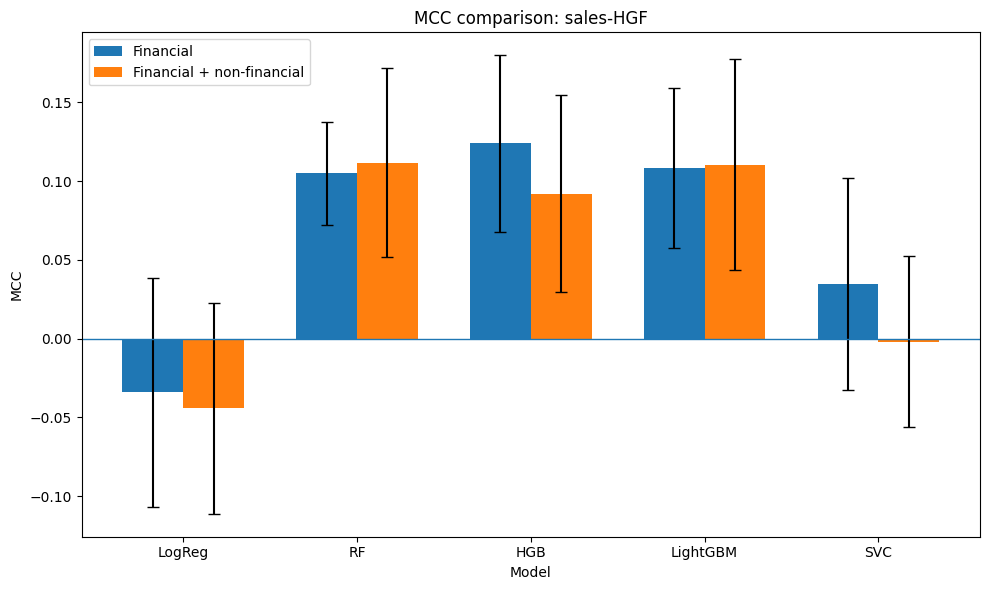

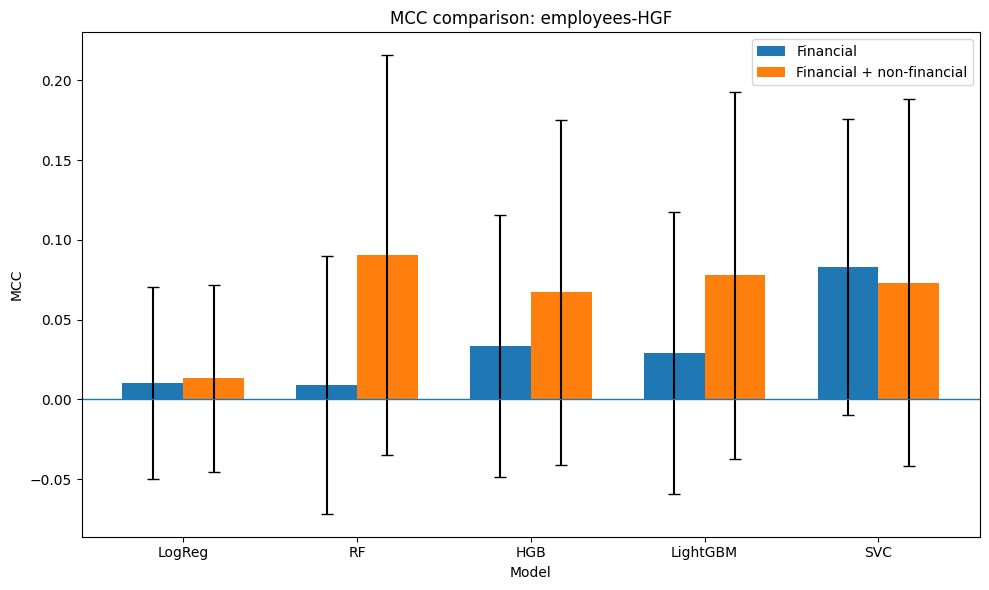

In [223]:
plot_mcc_comparison(
    analysis_df,
    "sales"
)

plot_mcc_comparison(
    analysis_df,
    "employees"
)

In [224]:
mcc_pivot = analysis_df.pivot(
    index=["target", "model"],
    columns="feature_set",
    values="MCC_mean"
).reset_index()

mcc_pivot["delta_MCC"] = (
    mcc_pivot["full"]
    - mcc_pivot["financial"]
)

mcc_pivot

feature_set,target,model,financial,full,delta_MCC
0,employees,HistGradientBoosting,0.033340,0.067000,0.033659
1,employees,LightGBM,0.029330,0.077834,0.048504
2,employees,LogisticRegression,0.010118,0.013246,0.003128
3,employees,RandomForest,0.009145,0.090483,0.081338
4,employees,SVC,0.082776,0.073016,-0.009759
5,sales,HistGradientBoosting,0.123937,0.091969,-0.031968
6,sales,LightGBM,0.108178,0.110479,0.002300
7,sales,LogisticRegression,-0.034203,-0.044279,-0.010076
8,sales,RandomForest,0.105005,0.111814,0.006809
9,sales,SVC,0.034441,-0.002094,-0.036535


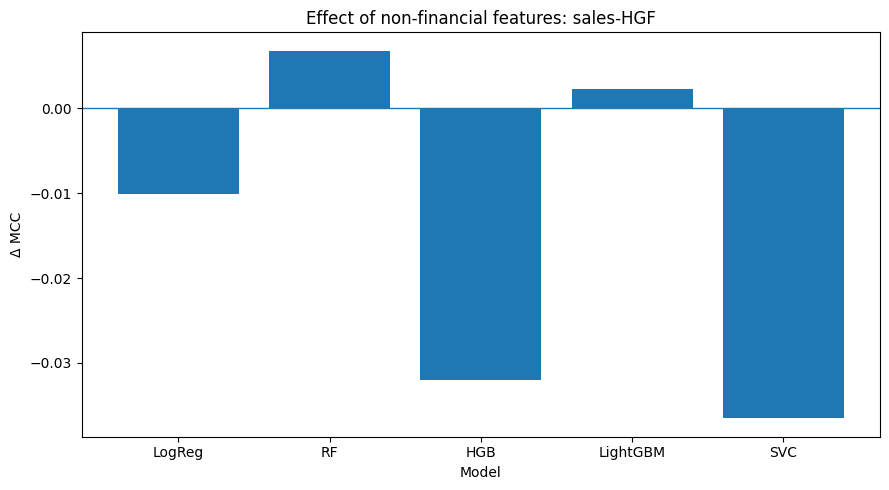

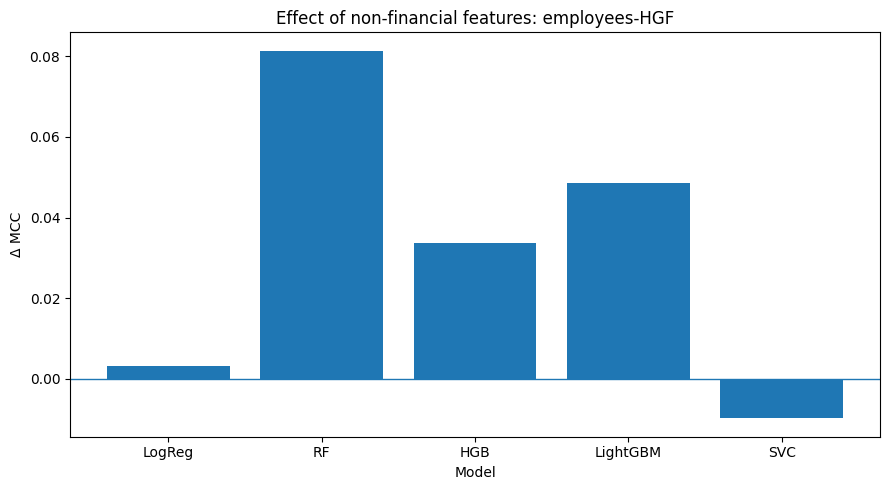

In [227]:
plot_mcc_delta(
    mcc_pivot,
    "sales"
)

plot_mcc_delta(
    mcc_pivot,
    "employees"
)

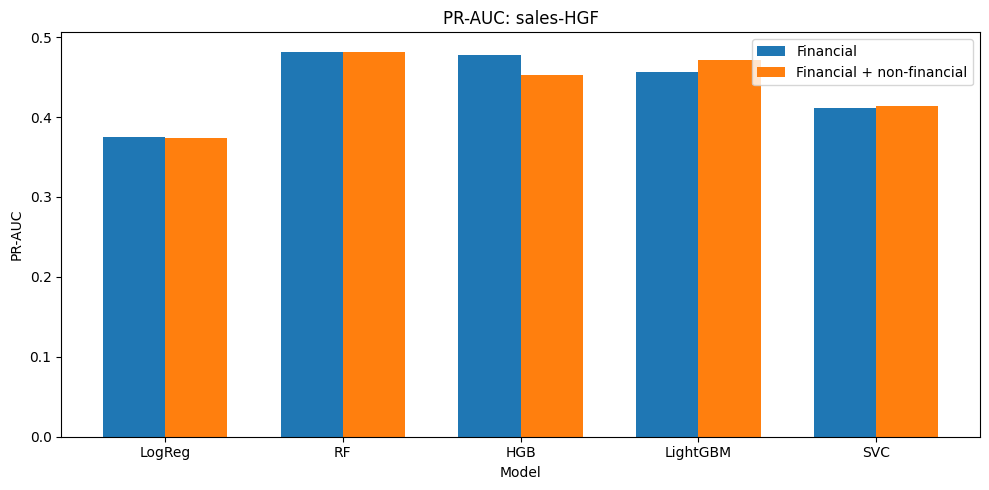

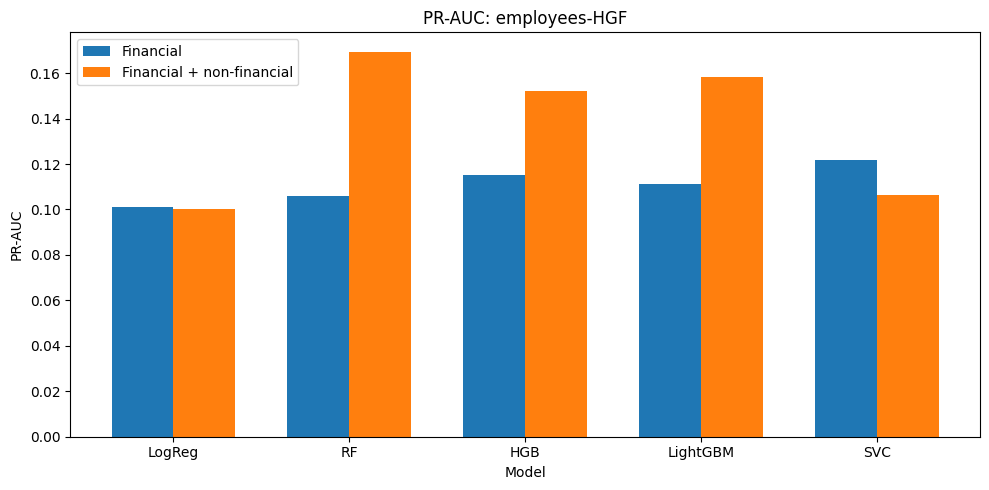

In [229]:
plot_metric_comparison(
    analysis_df,
    "sales",
    "PR-AUC_mean",
    "PR-AUC: sales-HGF"
)

plot_metric_comparison(
    analysis_df,
    "employees",
    "PR-AUC_mean",
    "PR-AUC: employees-HGF"
)

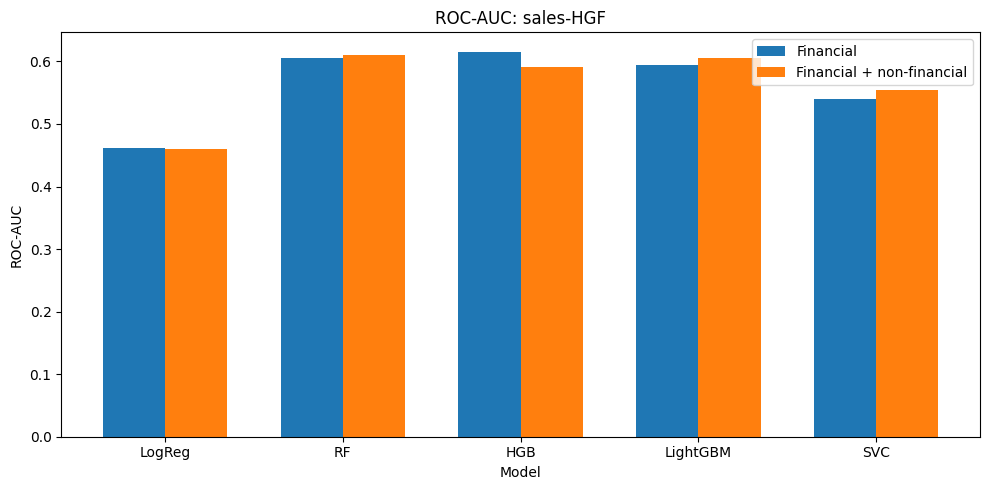

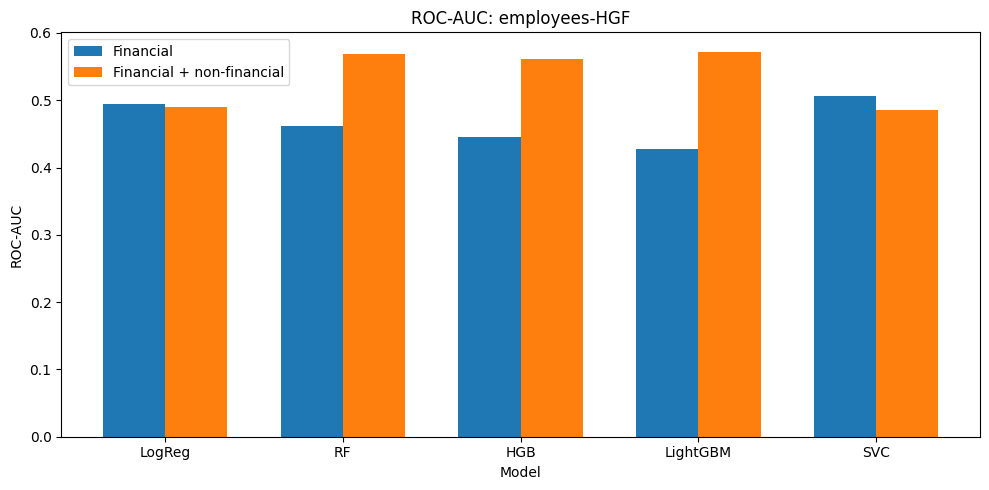

In [230]:
plot_metric_comparison(
    analysis_df,
    "sales",
    "ROC-AUC_mean",
    "ROC-AUC: sales-HGF"
)

plot_metric_comparison(
    analysis_df,
    "employees",
    "ROC-AUC_mean",
    "ROC-AUC: employees-HGF"
)

In [232]:
feature_effects

,target,model,MCC_mean_financial,MCC_mean_full,delta_MCC_mean,PR-AUC_mean_financial,PR-AUC_mean_full,delta_PR-AUC_mean,ROC-AUC_mean_financial,ROC-AUC_mean_full,delta_ROC-AUC_mean,F1_mean_financial,F1_mean_full,delta_F1_mean,Recall_mean_financial,Recall_mean_full,delta_Recall_mean
0,sales,LogisticRegression,-0.034203,-0.044279,-0.010076,0.375194,0.374314,-0.000880,0.461157,0.459334,-0.001823,0.372077,0.383705,0.011628,0.395755,0.427311,0.031556
1,sales,RandomForest,0.105005,0.111814,0.006809,0.481485,0.481895,0.000410,0.606285,0.610626,0.004341,0.220424,0.339997,0.119573,0.141873,0.265642,0.123769
2,sales,HistGradientBoosting,0.123937,0.091969,-0.031968,0.477287,0.453175,-0.024112,0.615771,0.590465,-0.025306,0.371230,0.367373,-0.003858,0.304393,0.313501,0.009108
3,sales,LightGBM,0.108178,0.110479,0.002300,0.456004,0.471867,0.015864,0.595052,0.604728,0.009675,0.383663,0.324560,-0.059103,0.330581,0.245786,-0.084796
4,sales,SVC,0.034441,-0.002094,-0.036535,0.411351,0.413960,0.002609,0.540731,0.553943,0.013212,0.047718,0.106734,0.059016,0.025287,0.063211,0.037924
5,employees,LogisticRegression,0.010118,0.013246,0.003128,0.100897,0.100249,-0.000648,0.494185,0.490113,-0.004072,0.150398,0.150752,0.000354,0.550763,0.523747,-0.027015
6,employees,RandomForest,0.009145,0.090483,0.081338,0.106010,0.169480,0.063470,0.461291,0.568958,0.107667,0.049501,0.059964,0.010464,0.034858,0.034858,0.000000
7,employees,HistGradientBoosting,0.033340,0.067000,0.033659,0.115046,0.152176,0.037130,0.444712,0.561579,0.116867,0.059920,0.060222,0.000302,0.038780,0.035076,-0.003704
8,employees,LightGBM,0.029330,0.077834,0.048504,0.111244,0.158238,0.046994,0.427871,0.572256,0.144386,0.059350,0.072597,0.013248,0.038344,0.042702,0.004357
9,employees,SVC,0.082776,0.073016,-0.009759,0.121874,0.106494,-0.015380,0.506641,0.485442,-0.021199,0.055867,0.042996,-0.012871,0.030937,0.023312,-0.007625


#### Выводы

По результатам обучения можно сделать следующие выводы:

Рассматривая sales-HGF наибольший вклад вносят исключительно финансовые признаки. При добавлении нефинансовых признаков, ансамблевые модели сильно теряют в качестве, что выражается в ухудшении значений ключевых метрик, таких как MCC, PR-AUC и ROC-AUC. Особенно хорошо это видно на SVC модели, чья MCC улучшилась с ~0 до ~0.04.

Но важно отметить, что при исследовании employee-HGF фирм, ситуация меняется и нефинансовые признаки дают значительный прирост для ансамблевых моделей. Однако, в связи с добавлением, значительно превосходящего количество финансовых признаков, числа нефинансовых признаков увеличивается и отклонение значений метрик на кросс-валидации.

Лучшей моделью для выявления sales-HGF фирм при помощи финансовых признаков является HistGradientBoost

### Дополнительное исследование

Дополнительное исследование посвящено анализу расхождений метрик между моделями, обученными на финансовых и нефинансовых признаках, внутри каждой различной выборки между соответствующими валидациями.

##### Подготовка функций

In [236]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score


def prepare_cv_model(model):

    model = clone(model)

    # Не допускаем двойного распараллеливания
    if "n_jobs" in model.get_params():
        model.set_params(n_jobs=1)

    return model


def paired_cv_comparison(
    model_full,
    model_financial,
    X_full,
    X_financial,
    y,
    splits,
    target,
    model_name
):

    full_scores = cross_val_score(
        prepare_cv_model(model_full),
        X_full,
        y,
        cv=splits,
        scoring=mcc_scorer,
        n_jobs=-1
    )

    financial_scores = cross_val_score(
        prepare_cv_model(model_financial),
        X_financial,
        y,
        cv=splits,
        scoring=mcc_scorer,
        n_jobs=-1
    )

    n = len(full_scores)

    result = pd.DataFrame({
        "target": target,
        "model": model_name,

        "split": np.arange(1, n + 1),

        "repeat": (
            np.arange(n) // 5 + 1
        ),

        "fold": (
            np.arange(n) % 5 + 1
        ),

        "MCC_financial": financial_scores,
        "MCC_full": full_scores
    })

    result["delta_MCC"] = (
        result["MCC_full"]
        - result["MCC_financial"]
    )

    return result

In [237]:
paired_tasks = [

    # SALES

    (
        "sales",
        "LogisticRegression",
        logreg_sales,
        logreg_sales_fin,
        X_train_sales_linear,
        X_train_sales_linear_financial,
        y_train_sales,
        sales_cv_splits
    ),

    (
        "sales",
        "RandomForest",
        rf_sales,
        rf_sales_fin,
        X_train_sales_tree,
        X_train_sales_tree_financial,
        y_train_sales,
        sales_cv_splits
    ),

    (
        "sales",
        "HistGradientBoosting",
        hgb_sales,
        hgb_sales_fin,
        X_train_sales_tree,
        X_train_sales_tree_financial,
        y_train_sales,
        sales_cv_splits
    ),

    (
        "sales",
        "LightGBM",
        lgbm_sales,
        lgbm_sales_fin,
        X_train_sales_tree,
        X_train_sales_tree_financial,
        y_train_sales,
        sales_cv_splits
    ),

    (
        "sales",
        "SVC",
        svc_sales,
        svc_sales_fin,
        X_train_sales_linear,
        X_train_sales_linear_financial,
        y_train_sales,
        sales_cv_splits
    ),


    # EMPLOYEES

    (
        "employees",
        "LogisticRegression",
        logreg_employees,
        logreg_employees_fin,
        X_train_employees_linear,
        X_train_employees_linear_financial,
        y_train_employees,
        employees_cv_splits
    ),

    (
        "employees",
        "RandomForest",
        rf_employees,
        rf_employees_fin,
        X_train_employees_tree,
        X_train_employees_tree_financial,
        y_train_employees,
        employees_cv_splits
    ),

    (
        "employees",
        "HistGradientBoosting",
        hgb_employees,
        hgb_employees_fin,
        X_train_employees_tree,
        X_train_employees_tree_financial,
        y_train_employees,
        employees_cv_splits
    ),

    (
        "employees",
        "LightGBM",
        lgbm_employees,
        lgbm_employees_fin,
        X_train_employees_tree,
        X_train_employees_tree_financial,
        y_train_employees,
        employees_cv_splits
    ),

    (
        "employees",
        "SVC",
        svc_employees,
        svc_employees_fin,
        X_train_employees_linear,
        X_train_employees_linear_financial,
        y_train_employees,
        employees_cv_splits
    )
]

In [238]:
paired_results_list = []

for (
    target,
    model_name,
    model_full,
    model_financial,
    X_full,
    X_financial,
    y,
    splits
) in paired_tasks:

    print(
        f"Paired CV: {target} | {model_name}"
    )

    result = paired_cv_comparison(
        model_full=model_full,
        model_financial=model_financial,
        X_full=X_full,
        X_financial=X_financial,
        y=y,
        splits=splits,
        target=target,
        model_name=model_name
    )

    paired_results_list.append(result)


paired_cv_results = pd.concat(
    paired_results_list,
    ignore_index=True
)

paired_cv_results

Paired CV: sales | LogisticRegression
Paired CV: sales | RandomForest
Paired CV: sales | HistGradientBoosting
Paired CV: sales | LightGBM
Paired CV: sales | SVC
Paired CV: employees | LogisticRegression
Paired CV: employees | RandomForest
Paired CV: employees | HistGradientBoosting
Paired CV: employees | LightGBM
Paired CV: employees | SVC


,target,model,split,repeat,fold,MCC_financial,MCC_full,delta_MCC
0,sales,LogisticRegression,1,1,1,0.088194,0.042400,-0.045794
1,sales,LogisticRegression,2,1,2,-0.026024,-0.041556,-0.015532
2,sales,LogisticRegression,3,1,3,-0.148623,-0.159176,-0.010553
3,sales,LogisticRegression,4,1,4,0.001973,0.020869,0.018896
4,sales,LogisticRegression,5,1,5,-0.090721,-0.107272,-0.016551
5,sales,LogisticRegression,6,2,1,-0.098909,-0.133140,-0.034231
6,sales,LogisticRegression,7,2,2,-0.009763,0.029994,0.039757
7,sales,LogisticRegression,8,2,3,-0.017112,-0.024847,-0.007735
8,sales,LogisticRegression,9,2,4,-0.088697,-0.123718,-0.035022
9,sales,LogisticRegression,10,2,5,-0.030139,-0.029444,0.000696


In [239]:
def summarize_paired_cv(group):

    delta = group["delta_MCC"]

    return pd.Series({
        "MCC_financial_mean":
            group["MCC_financial"].mean(),

        "MCC_full_mean":
            group["MCC_full"].mean(),

        "delta_MCC_mean":
            delta.mean(),

        "delta_MCC_median":
            delta.median(),

        "delta_MCC_std":
            delta.std(),

        "improved_folds":
            (delta > 0).sum(),

        "worsened_folds":
            (delta < 0).sum(),

        "equal_folds":
            np.isclose(delta, 0).sum(),

        "improved_share":
            (delta > 0).mean()
    })


paired_cv_summary = (
    paired_cv_results
    .groupby(
        ["target", "model"]
    )
    .apply(summarize_paired_cv)
    .reset_index()
)

paired_cv_summary = (
    paired_cv_summary
    .sort_values(
        ["target", "delta_MCC_mean"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

paired_cv_summary

,target,model,MCC_financial_mean,MCC_full_mean,delta_MCC_mean,delta_MCC_median,delta_MCC_std,improved_folds,worsened_folds,equal_folds,improved_share
0,employees,RandomForest,0.009145,0.090483,0.081338,0.052486,0.152058,12.0,3.0,0.0,0.800000
1,employees,LightGBM,0.029330,0.077834,0.048504,0.039501,0.158677,9.0,4.0,2.0,0.600000
2,employees,HistGradientBoosting,0.033340,0.067000,0.033659,0.013040,0.124028,9.0,6.0,0.0,0.600000
3,employees,LogisticRegression,0.010118,0.013246,0.003128,0.002967,0.038043,9.0,6.0,0.0,0.600000
4,employees,SVC,0.082776,0.073016,-0.009759,-0.008840,0.153289,6.0,8.0,1.0,0.400000
5,sales,RandomForest,0.105005,0.111814,0.006809,0.004532,0.043049,8.0,7.0,0.0,0.533333
6,sales,LightGBM,0.108178,0.110479,0.002300,-0.001294,0.076093,7.0,8.0,0.0,0.466667
7,sales,LogisticRegression,-0.034203,-0.044279,-0.010076,-0.013062,0.030272,5.0,10.0,0.0,0.333333
8,sales,HistGradientBoosting,0.123937,0.091969,-0.031968,-0.023024,0.069515,5.0,10.0,0.0,0.333333
9,sales,SVC,0.034441,-0.002094,-0.036535,-0.043485,0.107887,6.0,8.0,1.0,0.400000


In [243]:
def plot_paired_deltas(df, target):

    data = df[
        df["target"] == target
    ]

    plt.figure(figsize=(10, 6))

    x_positions = np.arange(
        len(MODEL_ORDER)
    )

    for i, model in enumerate(MODEL_ORDER):

        values = (
            data[
                data["model"] == model
            ]
            .sort_values("split")
            ["delta_MCC"]
            .values
        )

        # Небольшое фиксированное смещение,
        # чтобы точки не лежали друг на друге
        offsets = np.linspace(
            -0.12,
            0.12,
            len(values)
        )

        plt.scatter(
            np.full(len(values), i)
            + offsets,
            values,
            alpha=0.7
        )

        # Среднее значение
        plt.scatter(
            i,
            values.mean(),
            marker="D",
            s=80
        )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.xticks(
        x_positions,
        [
            MODEL_LABELS[m]
            for m in MODEL_ORDER
        ]
    )

    plt.ylabel(
        "Δ MCC (Full − Financial)"
    )

    plt.xlabel("Model")

    plt.title(
        f"Effect of non-financial features across CV folds: {target}-HGF"
    )

    plt.tight_layout()
    plt.show()

#### Результаты и анализ

In [241]:
paired_cv_results

,target,model,split,repeat,fold,MCC_financial,MCC_full,delta_MCC
0,sales,LogisticRegression,1,1,1,0.088194,0.042400,-0.045794
1,sales,LogisticRegression,2,1,2,-0.026024,-0.041556,-0.015532
2,sales,LogisticRegression,3,1,3,-0.148623,-0.159176,-0.010553
3,sales,LogisticRegression,4,1,4,0.001973,0.020869,0.018896
4,sales,LogisticRegression,5,1,5,-0.090721,-0.107272,-0.016551
5,sales,LogisticRegression,6,2,1,-0.098909,-0.133140,-0.034231
6,sales,LogisticRegression,7,2,2,-0.009763,0.029994,0.039757
7,sales,LogisticRegression,8,2,3,-0.017112,-0.024847,-0.007735
8,sales,LogisticRegression,9,2,4,-0.088697,-0.123718,-0.035022
9,sales,LogisticRegression,10,2,5,-0.030139,-0.029444,0.000696


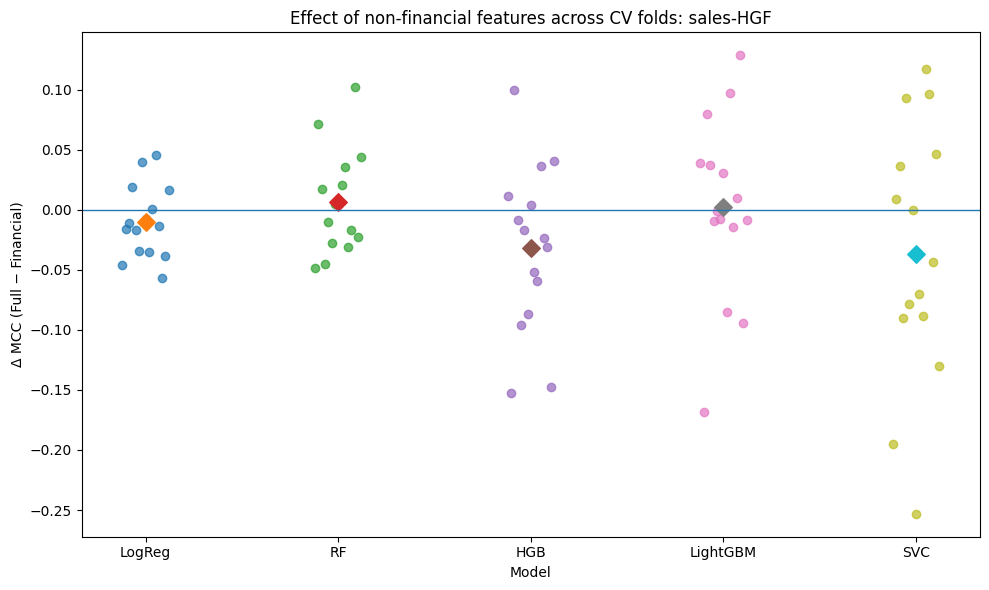

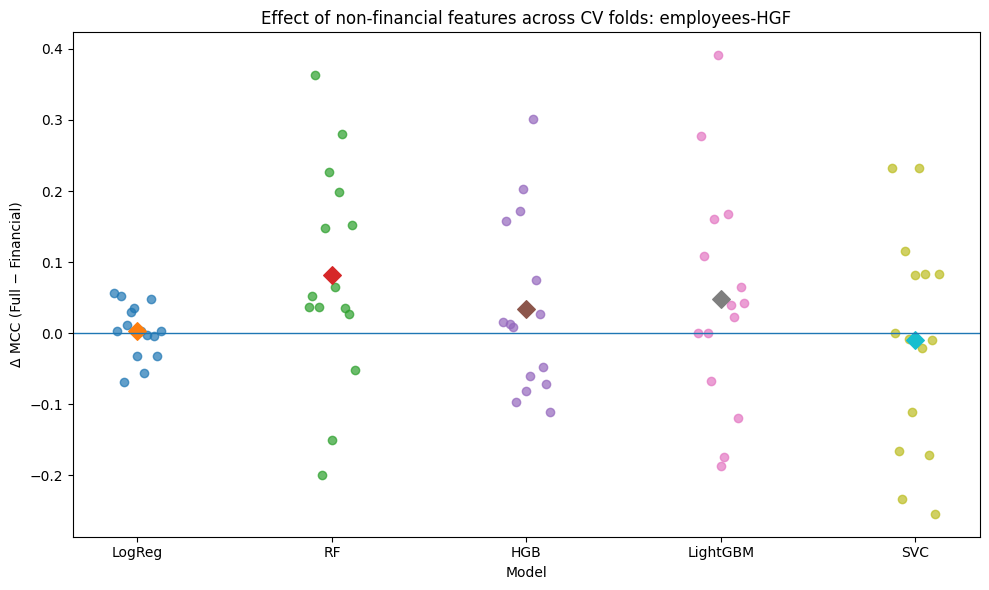

In [244]:
plot_paired_deltas(
    paired_cv_results,
    "sales"
)

plot_paired_deltas(
    paired_cv_results,
    "employees"
)

### Выводы по дополнительному исследованию

Дополнительное исследование показало, что, рассмаривая как sales-HGF, так и как employee-HGF, для всех моделей динамика расхождения метрик соответсвует конечному значению на всей повторяющейся кросс-валидации.

### Анализ финансовых признаков

Данный раздел посвящен выявлению наиболее информативных и значимых для HistGradientBoost модели финансовых признаков.

#### Результаты feature importance анализа

In [258]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


pi_hgb_sales = permutation_importance(
    hgb_sales_fin,
    X_test_sales_tree_financial,
    y_test_sales,
    scoring=mcc_scorer,
    n_repeats=50,
    random_state=42,
    n_jobs=-1
)


sales_hgb_importance = pd.DataFrame({
    "feature": X_test_sales_tree_financial.columns,
    "importance_mean": pi_hgb_sales.importances_mean,
    "importance_std": pi_hgb_sales.importances_std
})

sales_hgb_importance = (
    sales_hgb_importance
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

sales_hgb_importance.head(20)

,feature,importance_mean,importance_std
0,country,0.042865,0.043196
1,n3,0.023489,0.030191
2,n2a,0.014419,0.030180
3,n2b,0.011966,0.026860
4,n2e,0.010144,0.025288
5,k5a_status,0.008981,0.009866
6,k21,0.004575,0.004396
7,k5a,0.003965,0.019318
8,d2,0.002669,0.024123
9,k5f,0.000000,0.000000


In [259]:
def get_base_feature(feature):

    if feature.endswith("_status"):
        return feature.replace("_status", "")

    return feature


sales_hgb_importance["base_feature"] = (
    sales_hgb_importance["feature"]
    .apply(get_base_feature)
)


sales_hgb_importance["description"] = (
    sales_hgb_importance["base_feature"]
    .map(FEATURES)
)


sales_hgb_importance.loc[
    sales_hgb_importance["feature"] == "country",
    "description"
] = "Страна"

In [266]:
# sales_hgb_importance[
#     [
#         "feature",
#         "description",
#         "importance_mean",
#         "importance_std"
#     ]
# ].head(20)

In [261]:
sales_hgb_importance["feature_type"] = np.where(
    sales_hgb_importance["feature"].str.endswith("_status"),
    "missing_status",
    "financial"
)

sales_hgb_importance.loc[
    sales_hgb_importance["feature"] == "country",
    "feature_type"
] = "control"

In [262]:
sales_financial_importance = (
    sales_hgb_importance[
        sales_hgb_importance["feature_type"] == "financial"
    ]
    .copy()
)

sales_financial_importance.head(15)

,feature,importance_mean,importance_std,base_feature,description,feature_type
1,n3,0.023489,0.030191,n3,Продажи фирмы три финансовых года назад,financial
2,n2a,0.014419,0.030180,n2a,"Общие затраты на труд, включая заработную плат...",financial
3,n2b,0.011966,0.026860,n2b,Расходы на электроэнергию,financial
4,n2e,0.010144,0.025288,n2e,Расходы на сырье и промежуточные материалы,financial
6,k21,0.004575,0.004396,k21,Проверялась ли финансовая отчетность внешним а...,financial
7,k5a,0.003965,0.019318,k5a,"Доля инвестиций, профинансированная за счет со...",financial
8,d2,0.002669,0.024123,d2,Продажи фирмы за последний завершенный финансо...,financial
9,k5f,0.000000,0.000000,k5f,"Доля инвестиций, профинансированная за счет кр...",financial
16,k5i,0.000000,0.000000,k5i,"Доля инвестиций, профинансированная за счет вк...",financial
19,k11,-0.001220,0.014714,k11,Размер последнего кредита на момент его одобрения,financial


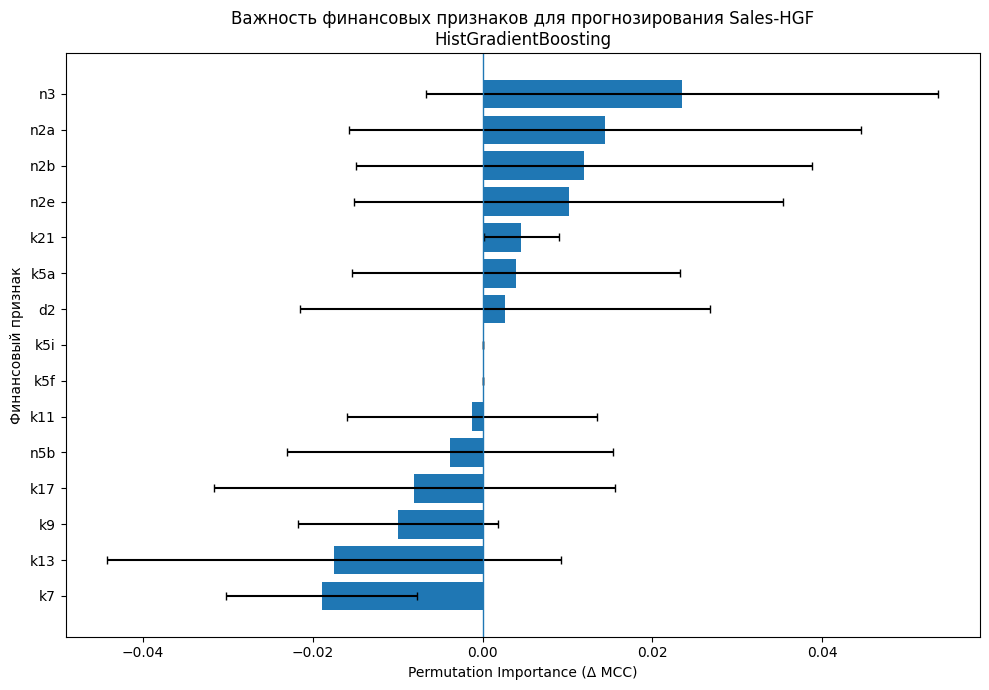

In [265]:
top_sales = (
    sales_financial_importance
    .head(15)
    .sort_values(
        "importance_mean",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_sales["feature"],
    top_sales["importance_mean"],
    xerr=top_sales["importance_std"],
    capsize=3
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Permutation Importance (Δ MCC)")
plt.ylabel("Финансовый признак")

plt.title(
    "Важность финансовых признаков для прогнозирования Sales-HGF\n"
    "HistGradientBoosting"
)

plt.tight_layout()
plt.show()

#### Выводы по feature importance

Проведенный анализ перестановки признаков показал, что все признаки имеют крайне большое отклонение, что говорит о неустойчивости важности каждого из них, а значит судить о важности при таких значениях нужно осторожно.

Отслеживая динамику отклонения признаков n3, n2a, n2b и n2e, можно сказать, что они играют наиболее значимую роль в пресдказании, и явно выделяются на фоне остальных. То есть для модели важнее знать, какие продажи были 3 года назад и какие средства фирма выделяла на труд, электроэнергию и сырье.

##### Дополнительное исследование

Отдельного внимание требует влияние признака country. Географическое положение правда может оказывать сильное влияние на возможность финансового роста компании.

In [267]:
X_train_sales_fin_no_country = (
    X_train_sales_tree_financial
    .drop(columns=["country"])
    .copy()
)

X_test_sales_fin_no_country = (
    X_test_sales_tree_financial
    .drop(columns=["country"])
    .copy()
)

print(X_train_sales_fin_no_country.shape)

(992, 33)


In [268]:
from sklearn.preprocessing import OneHotEncoder

country_ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

country_train = country_ohe.fit_transform(
    X_train_sales_tree_financial[["country"]]
)

country_test = country_ohe.transform(
    X_test_sales_tree_financial[["country"]]
)

country_columns = [
    f"country_{value}"
    for value in country_ohe.categories_[0]
]

country_train = pd.DataFrame(
    country_train,
    columns=country_columns,
    index=X_train_sales_tree_financial.index
)

country_test = pd.DataFrame(
    country_test,
    columns=country_columns,
    index=X_test_sales_tree_financial.index
)

In [271]:
X_train_sales_fin_country_ohe = pd.concat(
    [
        X_train_sales_fin_no_country,
        country_train
    ],
    axis=1
)

X_test_sales_fin_country_ohe = pd.concat(
    [
        X_test_sales_fin_no_country,
        country_test
    ],
    axis=1
)

print(
    X_train_sales_tree_financial.shape,
    X_train_sales_fin_no_country.shape,
    X_train_sales_fin_country_ohe.shape
)

(992, 34) (992, 33) (992, 42)


In [272]:
from sklearn.preprocessing import OneHotEncoder

country_ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

country_train = country_ohe.fit_transform(
    X_train_sales_tree_financial[["country"]]
)

country_test = country_ohe.transform(
    X_test_sales_tree_financial[["country"]]
)

country_columns = [
    f"country_{value}"
    for value in country_ohe.categories_[0]
]

country_train = pd.DataFrame(
    country_train,
    columns=country_columns,
    index=X_train_sales_tree_financial.index
)

country_test = pd.DataFrame(
    country_test,
    columns=country_columns,
    index=X_test_sales_tree_financial.index
)

In [273]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_score


def country_cv(model, X):

    return cross_val_score(
        clone(model),
        X,
        y_train_sales,
        cv=sales_cv_splits,
        scoring=mcc_scorer,
        n_jobs=-1
    )


scores_country_ordinal = country_cv(
    hgb_sales_fin,
    X_train_sales_tree_financial
)

scores_country_ohe = country_cv(
    hgb_sales_fin,
    X_train_sales_fin_country_ohe
)

scores_no_country = country_cv(
    hgb_sales_fin,
    X_train_sales_fin_no_country
)

In [274]:
country_check = pd.DataFrame({
    "variant": [
        "Country ordinal",
        "Country one-hot",
        "Without country"
    ],

    "MCC_mean": [
        scores_country_ordinal.mean(),
        scores_country_ohe.mean(),
        scores_no_country.mean()
    ],

    "MCC_std": [
        scores_country_ordinal.std(),
        scores_country_ohe.std(),
        scores_no_country.std()
    ]
})

country_check

,variant,MCC_mean,MCC_std
0,Country ordinal,0.123937,0.056026
1,Country one-hot,0.131333,0.064248
2,Without country,0.047014,0.061650


##### Выводы по дополнительному исследованию

In [278]:
country_check

,variant,MCC_mean,MCC_std
0,Country ordinal,0.123937,0.056026
1,Country one-hot,0.131333,0.064248
2,Without country,0.047014,0.061650


После проверки работы модели на разных датасетах, можно сделать вывод о том, что модель распознает конкретные страны, в которых есть большие возможности для роста выручки. Это отражает различния во влиянии экономических, политических и других факторов на потенциал роста фирмы.

#### Результаты SHAP анализа моделей

In [280]:
explainer_sales = shap.TreeExplainer(
    hgb_sales_fin
)

shap_values_sales = explainer_sales(
    X_test_sales_tree_financial
)

print(shap_values_sales.shape)

(248, 34)


In [281]:
sales_financial_features = [
    col
    for col in X_test_sales_tree_financial.columns
    if (
        col in FINANCIAL_FEATURES
        and not col.endswith("_status")
    )
]

print(
    "Финансовых признаков:",
    len(sales_financial_features)
)

print(sales_financial_features)

Финансовых признаков: 20
['d2', 'n3', 'd1a3', 'n2a', 'n2b', 'n2e', 'n5a', 'n5b', 'n7a', 'k5a', 'k5f', 'k5i', 'k11', 'k4', 'k7', 'k13', 'k21', 'k9', 'k17', 'k30']


In [282]:
financial_indices = [
    X_test_sales_tree_financial.columns.get_loc(col)
    for col in sales_financial_features
]

shap_sales_financial = shap_values_sales[
    :,
    financial_indices
]

In [290]:
mean_abs_shap = np.abs(
    shap_sales_financial.values
).mean(axis=0)

sales_shap_importance = pd.DataFrame({
    "feature": sales_financial_features,
    "mean_abs_shap": mean_abs_shap
})

sales_shap_importance["description"] = (
    sales_shap_importance["feature"]
    .map(FEATURES)
)

sales_shap_importance = (
    sales_shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

sales_shap_importance.head(15)

,feature,mean_abs_shap,description
0,k30,0.141045,Насколько доступ к финансированию является пре...
1,n2a,0.114658,"Общие затраты на труд, включая заработную плат..."
2,n2b,0.105299,Расходы на электроэнергию
3,n3,0.096934,Продажи фирмы три финансовых года назад
4,k5a,0.094982,"Доля инвестиций, профинансированная за счет со..."
5,k4,0.094952,Приобретала ли фирма основные средства
6,n5a,0.088574,Инвестиции в машины и оборудование
7,n2e,0.087487,Расходы на сырье и промежуточные материалы
8,n7a,0.072017,Стоимость замещения имеющихся машин и оборудов...
9,n5b,0.071116,Инвестиции в землю и здания


In [292]:
top_shap_sales = (
    sales_shap_importance
    .head(10)
    .sort_values(
        "mean_abs_shap",
        ascending=True
    )
)

# plt.figure(figsize=(10, 6))

# plt.barh(
#     top_shap_sales["description"],
#     top_shap_sales["mean_abs_shap"]
# )

# plt.xlabel("Среднее |SHAP value|")
# plt.ylabel("Финансовый признак")

# plt.title(
#     "SHAP-важность финансовых признаков для Sales-HGF"
# )

# plt.tight_layout()
# plt.show()

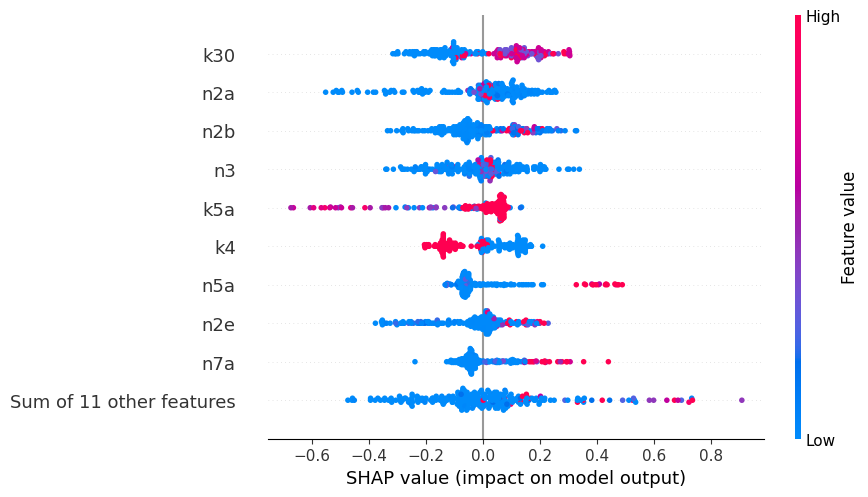

In [285]:
shap.plots.beeswarm(
    shap_sales_financial,
    max_display=10
)

In [287]:
TOP_N = 5

top_sales_features = (
    sales_shap_importance
    .head(TOP_N)["feature"]
    .tolist()
)

top_sales_features

['k30', 'n2a', 'n2b', 'n3', 'k5a']

k30 - Насколько доступ к финансированию является препятствием для деятельности фирмы


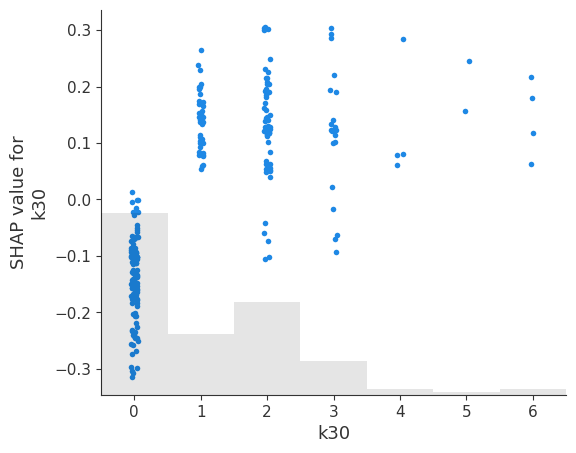

n2a - Общие затраты на труд, включая заработную плату и выплаты работникам


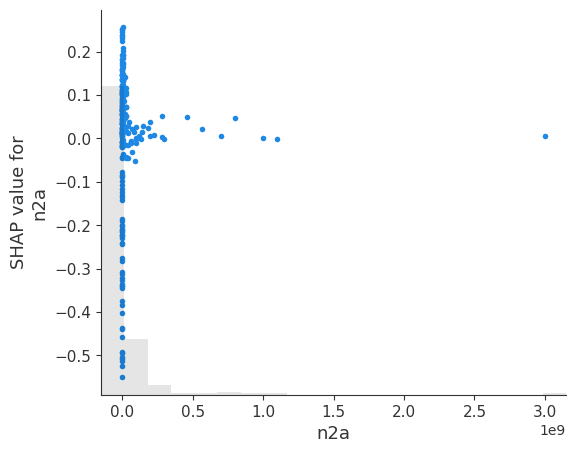

n2b - Расходы на электроэнергию


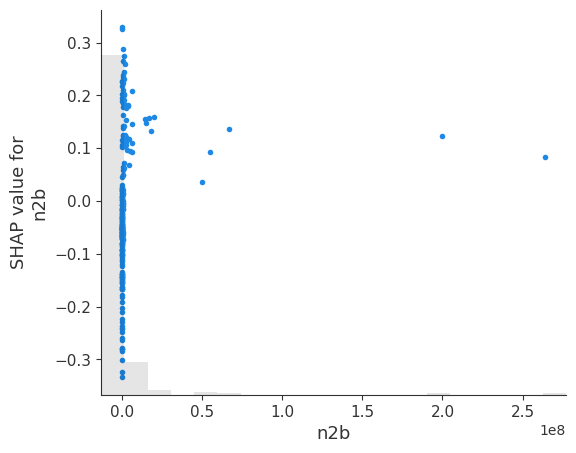

n3 - Продажи фирмы три финансовых года назад


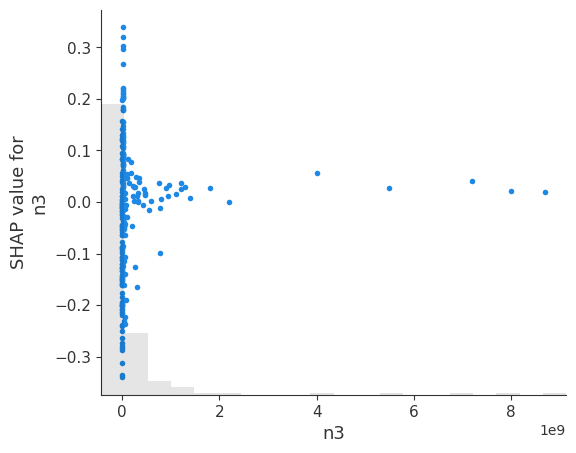

k5a - Доля инвестиций, профинансированная за счет собственных средств


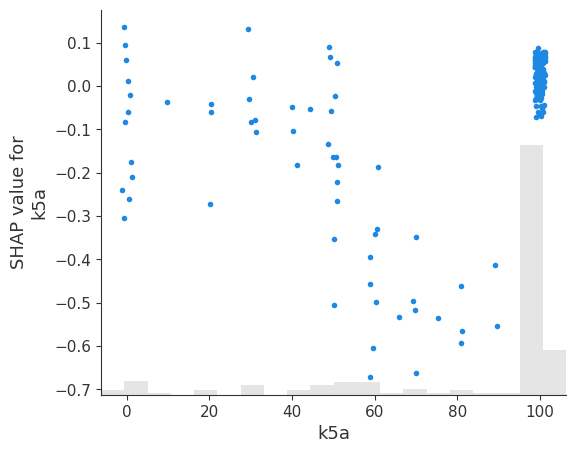

In [288]:
for feature in top_sales_features:

    print(
        feature,
        "-",
        FEATURES.get(feature, feature)
    )

    shap.plots.scatter(
        shap_sales_financial[:, feature]
    )

#### Вывод по shap анализу признаков

Наиболее показательными для SHAP являются k30, n2a, n2b, n3 и k5a. Для k5a наиболее показательным является крайнее значение 100, когда 100% инвестиций профинансировано лично основателем компании. Для n2a, n2b и n3 информативными являются крайне низкие значения коэффициентов, которые в совокупности и формируют наилучшее предсказание. Для k30 особенно интересны сильно выбивающиеся высокие значения, то есть доступ к финансированию наиболее сильно характеризует поведение модели.

Стоит отметить вклад признаков n5a и n7a, которые при принятии высоких значений сильно влияют на поведение модели

### Выводы по анализу финансовых признаков

Оба вида анализа не противоречат, а дополняют друг друга, что позволяет уверенно говорить о вкладе признаков для создания качественного предсказания модели. Оба анализа выделяют n2a, n2b, n3 и k5a как стабильно наиболее важные для модели признаки. Так же SHAP показывает важность k30, как наиболее определяющего модель финансового коэффициента.

### Анализ нефинансовых признаков

#### Анализ согласованности моделей

Для анализа согласованности всех трех ансамблевых моделей на основе решающих деревьев будет использоваться feature importnace для каждой, что позволит выявить, какие признаки они используют для создания лучших предсказаний.